# 🧠 Redes Neuronales con Scikit-Learn

## Curso de Iniciación al Machine Learning

---

### 📚 ¿Qué vas a aprender?

- ✅ Fundamentos teóricos de las redes neuronales
- ✅ Implementación práctica con scikit-learn
- ✅ Diferentes tipos de problemas (clasificación y regresión)
- ✅ Optimización de modelos y mejores prácticas
- ✅ Visualización e interpretación de resultados

### 🛠️ Herramientas que utilizaremos:
- **Scikit-learn**: Biblioteca principal para ML
- **NumPy**: Manipulación de datos
- **Pandas**: Análisis de datos
- **Matplotlib/Seaborn**: Visualizaciones
- **Datasets clásicos**: Iris, Digits, Boston Housing

## 📋 Tabla de Contenidos

1. [Fundamentos Teóricos](#1-fundamentos-teóricos)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Ejemplo Básico: Clasificación Iris](#3-ejemplo-básico-clasificación-iris)
4. [Ejemplo Intermedio: Reconocimiento de Dígitos](#4-ejemplo-intermedio-reconocimiento-de-dígitos)
5. [Ejemplo de Regresión: Predicción de Precios](#5-ejemplo-de-regresión-predicción-de-precios)
6. [Optimización Avanzada](#6-optimización-avanzada)
7. [Visualización y Diagnóstico](#7-visualización-y-diagnóstico)
8. [Mejores Prácticas](#8-mejores-prácticas)
9. [Ejercicios y Proyectos](#9-ejercicios-y-proyectos)

---

## 1. Fundamentos Teóricos

### ¿Qué es una Red Neuronal?

Una **red neuronal artificial** es un modelo computacional inspirado en cómo funciona el cerebro humano. Al igual que nuestro cerebro tiene neuronas conectadas entre sí, las redes neuronales tienen "neuronas artificiales" llamadas **perceptrones** que se conectan y procesan información.

### 🧠 Analogía Simple

Imagina que quieres decidir si ir a la playa:
- **Input (Entradas)**: ¿Está soleado? ¿Es fin de semana? ¿Tengo tiempo libre?
- **Procesamiento**: Tu cerebro evalúa cada factor y toma una decisión
- **Output (Salida)**: Ir o no ir a la playa

Una red neuronal hace exactamente esto, pero con números y matemáticas.

### Componentes Básicos

1. **Entrada (Input)**: Los datos que queremos procesar
2. **Pesos (Weights)**: Valores que indican la importancia de cada entrada
3. **Función de Activación**: Decide si una neurona "se activa" o no
4. **Salida (Output)**: El resultado final

### Funciones de Activación

Las funciones de activación determinan cuándo una neurona "dispara". Las más comunes son:

- **ReLU**: La más simple, pasa números positivos tal como están
- **Sigmoide**: Convierte valores a un rango entre 0 y 1
- **Tangente Hiperbólica**: Convierte valores a un rango entre -1 y 1

### Arquitectura de una Red Neuronal

```
Entrada → Capa Oculta 1 → Capa Oculta 2 → Salida
  (4)         (10)            (5)           (3)
```

- **Entrada**: Número de características (features) de tus datos
- **Capas Ocultas**: Donde ocurre la "magia" del procesamiento
- **Salida**: Número de clases (clasificación) o valor continuo (regresión)

### Algoritmo de Entrenamiento

Las redes neuronales aprenden ajustando sus pesos mediante:

1. **Forward Propagation**: Los datos fluyen desde la entrada hasta la salida
2. **Cálculo del Error**: Se compara la predicción con el valor real
3. **Backward Propagation**: El error se propaga hacia atrás para ajustar pesos
4. **Optimización**: Se usan algoritmos como SGD (Stochastic Gradient Descent)

### ¿Por qué usar Redes Neuronales?

#### ✅ Ventajas:
- Pueden aprender patrones complejos y no lineales
- Funcionan bien con grandes cantidades de datos
- Son versátiles (clasificación, regresión, reconocimiento de imágenes)
- Pueden capturar relaciones sutiles entre variables

#### ❌ Desventajas:
- Requieren muchos datos para funcionar bien
- Son "cajas negras" difíciles de interpretar
- Pueden sobreajustarse fácilmente
- Computacionalmente costosas de entrenar

### Cuándo Usar Redes Neuronales vs Otros Algoritmos

| Escenario | Algoritmo Recomendado | Razón |
|-----------|----------------------|-------|
| Datos estructurados pequeños (<1000 muestras) | Random Forest, SVM | Más interpretable, menos riesgo de overfitting |
| Datos estructurados grandes | Redes Neuronales | Pueden aprovechar el volumen de datos |
| Imágenes, audio, texto | Redes Neuronales especializadas | Necesarias arquitecturas específicas |
| Necesitas interpretabilidad | Tree-based models | Puedes ver qué características son importantes |
| Problema simple y rápido | Logistic Regression, Linear Regression | Solución simple y efectiva |

## 2. Configuración del Entorno

Antes de comenzar, vamos a configurar nuestro entorno de trabajo y importar todas las librerías necesarias.

In [2]:
%matplotlib inline
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.datasets import load_iris, load_digits
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
import warnings

# Configurar warnings para mostrar solo errores importantes
warnings.filterwarnings('ignore')

# Configurar matplotlib para modo no interactivo
# plt.switch_backend("Agg")

# Configurar estilo de gráficos
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

# Configurar fuentes para compatibilidad multiplataforma (más compatible con Windows)
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# Función auxiliar para mostrar gráficos
def setup_plot():
    """Configurar matplotlib para mostrar gráficos correctamente."""
    plt.figure(figsize=(10, 6))
    plt.tight_layout()
    plt.show()

print("✅ Entorno configurado correctamente!")

✅ Entorno configurado correctamente!


### 🎯 MLPClassifier y MLPRegressor de Scikit-Learn

Scikit-learn nos proporciona dos clases principales para redes neuronales:

- **MLPClassifier**: Para problemas de clasificación
- **MLPRegressor**: Para problemas de regresión

### Parámetros Principales

| Parámetro | Descripción | Valores Típicos |
|-----------|-------------|----------------|
| `hidden_layer_sizes` | Número de neuronas en cada capa oculta | (50,), (100, 50), (100, 50, 25) |
| `activation` | Función de activación | 'relu', 'tanh', 'logistic', 'identity' |
| `solver` | Algoritmo de optimización | 'adam', 'lbfgs', 'sgd' |
| `alpha` | Regularización L2 | 0.0001, 0.001, 0.01 |
| `learning_rate_init` | Velocidad de aprendizaje | 0.001, 0.01, 0.1 |
| `max_iter` | Máximo número de iteraciones | 200, 500, 1000 |

### 💡 Consejos para Elegir Parámetros

- **Capas ocultas**: Empezar simple (una capa) y aumentar gradualmente
- **Neuronas por capa**: Entre el tamaño de entrada y salida
- **ReLU**: Buena función de activación por defecto
- **Adam**: Solver recomendado para la mayoría de casos
- **Alpha**: Usar regularización para prevenir overfitting

## 3. Ejemplo Básico: Clasificación Iris

¡Comenzamos con el ejemplo más clásico del machine learning! El dataset **Iris** contiene información sobre 3 especies de flores (setosa, versicolor, virginica) basada en 4 características:

- Longitud del sépalo (cm)
- Ancho del sépalo (cm) 
- Longitud del pétalo (cm)
- Ancho del pétalo (cm)

Es perfecto para entender los conceptos básicos.

In [2]:
# Cargar el dataset Iris
iris = load_iris()
X, y = iris.data, iris.target

# Crear DataFrame para exploración
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['target'] = y
iris_df['species'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("📊 Información del Dataset Iris:")
print(f"Forma de los datos: {X.shape}")
print(f"Características: {iris.feature_names}")
print(f"Clases: {iris.target_names}")
print("\n📋 Primeras 5 muestras:")
iris_df.head()

📊 Información del Dataset Iris:
Forma de los datos: (150, 4)
Características: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases: ['setosa' 'versicolor' 'virginica']

📋 Primeras 5 muestras:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


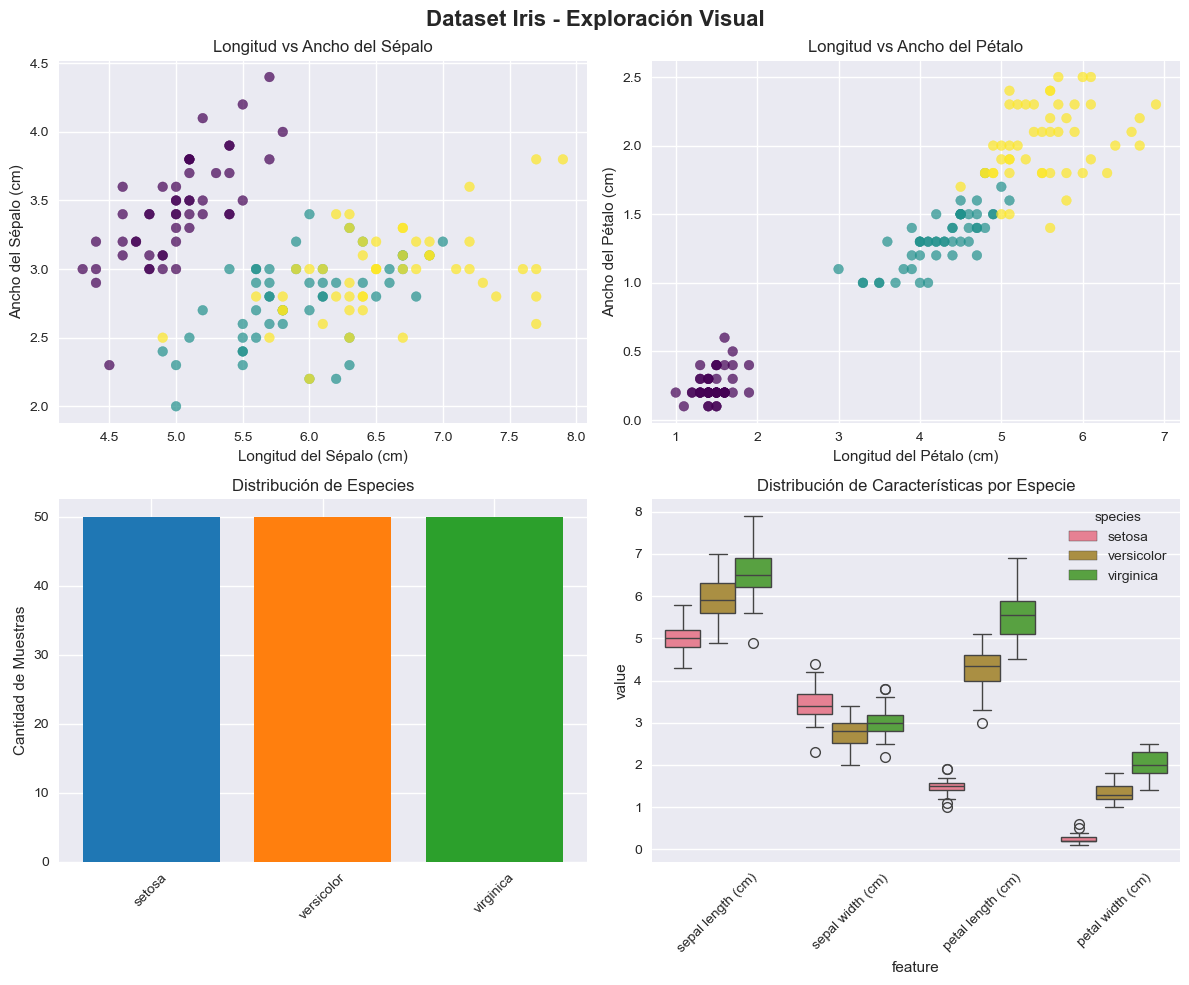

💡 Observaciones importantes:
- Setosa (azul) es claramente separable
- Versicolor y Virginica tienen cierta superposición
- Las características del pétalo son más discriminativas que las del sépalo


In [3]:
# Visualización exploratoria de los datos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Dataset Iris - Exploración Visual', fontsize=16, fontweight='bold')

# Gráfico de dispersión: longitud vs ancho del sépalo
scatter1 = axes[0, 0].scatter(iris_df['sepal length (cm)'], iris_df['sepal width (cm)'], 
                              c=iris_df['target'], cmap='viridis', alpha=0.7)
axes[0, 0].set_xlabel('Longitud del Sépalo (cm)')
axes[0, 0].set_ylabel('Ancho del Sépalo (cm)')
axes[0, 0].set_title('Longitud vs Ancho del Sépalo')

# Gráfico de dispersión: longitud vs ancho del pétalo
scatter2 = axes[0, 1].scatter(iris_df['petal length (cm)'], iris_df['petal width (cm)'], 
                              c=iris_df['target'], cmap='viridis', alpha=0.7)
axes[0, 1].set_xlabel('Longitud del Pétalo (cm)')
axes[0, 1].set_ylabel('Ancho del Pétalo (cm)')
axes[0, 1].set_title('Longitud vs Ancho del Pétalo')

# Distribución de clases
class_counts = iris_df['species'].value_counts()
axes[1, 0].bar(class_counts.index, class_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_title('Distribución de Especies')
axes[1, 0].set_ylabel('Cantidad de Muestras')
axes[1, 0].tick_params(axis='x', rotation=45)

# Box plot de características por especie
iris_melted = pd.melt(iris_df, 
                     id_vars=['species'], 
                     value_vars=iris.feature_names,
                     var_name='feature', 
                     value_name='value')
sns.boxplot(data=iris_melted, x='feature', y='value', hue='species', ax=axes[1, 1])
axes[1, 1].set_title('Distribución de Características por Especie')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
# plt.savefig('./iris_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("💡 Observaciones importantes:")
print("- Setosa (azul) es claramente separable")
print("- Versicolor y Virginica tienen cierta superposición")
print("- Las características del pétalo son más discriminativas que las del sépalo")

In [4]:
# División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("🔄 División de Datos:")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")
print(f"\nDistribución en entrenamiento:")
print(f"- Setosa: {sum(y_train == 0)} muestras")
print(f"- Versicolor: {sum(y_train == 1)} muestras")
print(f"- Virginica: {sum(y_train == 2)} muestras")

🔄 División de Datos:
Conjunto de entrenamiento: 105 muestras
Conjunto de prueba: 45 muestras

Distribución en entrenamiento:
- Setosa: 35 muestras
- Versicolor: 35 muestras
- Virginica: 35 muestras


In [5]:
# Normalización de datos (¡MUY IMPORTANTE para redes neuronales!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("📏 Datos Normalizados:")
print("Antes de normalización:")
print(f"Media: {X_train.mean(axis=0).round(2)}")
print(f"Desviación estándar: {X_train.std(axis=0).round(2)}")

print("\nDespués de normalización:")
print(f"Media: {X_train_scaled.mean(axis=0).round(2)}")
print(f"Desviación estándar: {X_train_scaled.std(axis=0).round(2)}")

print("\n💡 ¿Por qué normalizar?")
print("- Las redes neuronales son sensibles a la escala de los datos")
print("- Mejora la convergencia del entrenamiento")
print("- Evita que una característica domine sobre otras")
print("- StandardScaler normaliza a media 0 y desviación 1")

📏 Datos Normalizados:
Antes de normalización:
Media: [5.87 3.06 3.78 1.21]
Desviación estándar: [0.86 0.46 1.78 0.77]

Después de normalización:
Media: [ 0. -0. -0. -0.]
Desviación estándar: [1. 1. 1. 1.]

💡 ¿Por qué normalizar?
- Las redes neuronales son sensibles a la escala de los datos
- Mejora la convergencia del entrenamiento
- Evita que una característica domine sobre otras
- StandardScaler normaliza a media 0 y desviación 1


In [16]:
# Crear y entrenar la red neuronal
print("🧠 Creando la Red Neuronal...")

# Configuración básica de la red
mlp = MLPClassifier(
    hidden_layer_sizes=(10,),  # Una capa oculta con 10 neuronas
    activation='relu',         # Función de activación ReLU
    solver='adam',             # Algoritmo de optimización Adam
    alpha=0.001,               # Regularización L2
    learning_rate_init=0.001,   # Velocidad de aprendizaje inicial
    max_iter=1000,             # Máximo número de iteraciones
    random_state=42            # Para reproducibilidad
)

# Entrenar el modelo
print("⚡ Entrenando el modelo...")
mlp.fit(X_train_scaled, y_train)

print("✅ ¡Entrenamiento completado!")
print(f"📈 Número de iteraciones realizadas: {mlp.n_iter_}")
print(f"📊 Pérdida final: {mlp.loss_:.4f}")

# Hacer predicciones
y_pred_train = mlp.predict(X_train_scaled)
y_pred_test = mlp.predict(X_test_scaled)

print("\n🎯 Predicciones realizadas")
print(f"Conjunto de entrenamiento: {(y_pred_train == y_train).sum()}/{len(y_train)} correctas")
print(f"Conjunto de prueba: {(y_pred_test == y_test).sum()}/{len(y_test)} correctas")

🧠 Creando la Red Neuronal...
⚡ Entrenando el modelo...
✅ ¡Entrenamiento completado!
📈 Número de iteraciones realizadas: 1000
📊 Pérdida final: 0.0804

🎯 Predicciones realizadas
Conjunto de entrenamiento: 102/105 correctas
Conjunto de prueba: 43/45 correctas


In [17]:
# Evaluar el modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calcular precisión
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("📊 EVALUACIÓN DEL MODELO")
print("="*40)
print(f"🎯 Precisión en entrenamiento: {train_accuracy:.3f} ({train_accuracy*100:.1f}%)")
print(f"🎯 Precisión en prueba: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")

# Verificar overfitting
overfitting = train_accuracy - test_accuracy
if overfitting > 0.05:
    print(f"⚠️ Posible overfitting detectado: {overfitting:.3f}")
elif overfitting < -0.02:
    print(f"⚠️ Posible underfitting detectado: {abs(overfitting):.3f}")
else:
    print("✅ Buen balance entre bias y varianza")

# Reporte detallado de clasificación
print("\n📋 Reporte de Clasificación (Conjunto de Prueba):")
print(classification_report(y_test, y_pred_test, target_names=iris.target_names))

📊 EVALUACIÓN DEL MODELO
🎯 Precisión en entrenamiento: 0.971 (97.1%)
🎯 Precisión en prueba: 0.956 (95.6%)
✅ Buen balance entre bias y varianza

📋 Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



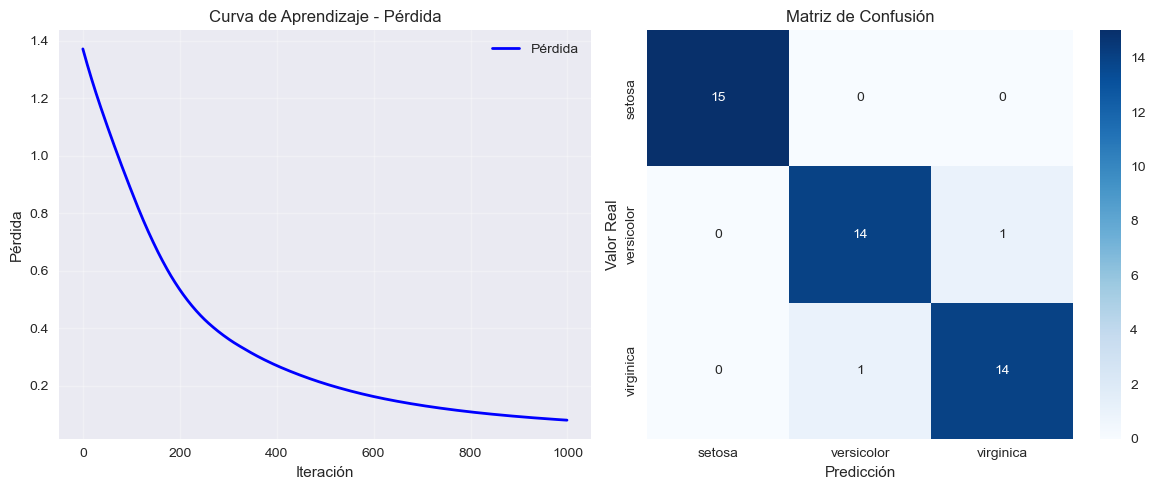

🔍 Análisis de Errores:
Setosa correctamente clasificada: 15/15 (100.0%)
Versicolor correctamente clasificada: 14/15 (93.3%)
Virginica correctamente clasificada: 14/15 (93.3%)

💡 Observación: Versicolor y Virginica a veces se confunden entre sí
Esto es normal y esperado debido a la superposición natural en el dataset.


In [18]:
# Visualizar la curva de aprendizaje
plt.figure(figsize=(12, 5))

# Gráfico 1: Curva de pérdida
plt.subplot(1, 2, 1)
plt.plot(mlp.loss_curve_, 'b-', linewidth=2, label='Pérdida')
plt.title('Curva de Aprendizaje - Pérdida')
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: Matriz de confusión
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.tight_layout()
# plt.savefig('./iris_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# Análisis de la matriz de confusión
print("🔍 Análisis de Errores:")
print(f"Setosa correctamente clasificada: {cm[0,0]}/{cm[0,:].sum()} ({cm[0,0]/cm[0,:].sum()*100:.1f}%)")
print(f"Versicolor correctamente clasificada: {cm[1,1]}/{cm[1,:].sum()} ({cm[1,1]/cm[1,:].sum()*100:.1f}%)")
print(f"Virginica correctamente clasificada: {cm[2,2]}/{cm[2,:].sum()} ({cm[2,2]/cm[2,:].sum()*100:.1f}%)")

if cm[1,2] > 0 or cm[2,1] > 0:
    print("\n💡 Observación: Versicolor y Virginica a veces se confunden entre sí")
print("Esto es normal y esperado debido a la superposición natural en el dataset.")

### 🎯 Resumen del Ejemplo Iris

**¿Qué aprendimos?**
- ✅ Las redes neuronales pueden resolver problemas de clasificación multiclase
- ✅ La normalización es crucial para el buen funcionamiento
- ✅ Una arquitectura simple (1 capa oculta, 10 neuronas) puede ser muy efectiva
- ✅ Cómo interpretar las métricas de evaluación

**Configuración utilizada:**
- 1 capa oculta con 10 neuronas
- Función de activación ReLU
- Solver Adam
- Regularización L2 (alpha=0.001)
- Resultados: ~95% de precisión en prueba

**Próximo paso:** Vamos a un problema más complejo: reconocimiento de dígitos escritos a mano.

## 4. Ejemplo Intermedio: Reconocimiento de Dígitos

Ahora vamos a un problema más desafiante: **reconocimiento de dígitos escritos a mano** del 0 al 9. 

Este dataset contiene:
- **8x8 píxeles** por imagen (64 características)
- **10 clases** (dígitos 0-9)
- **1,797 muestras** de entrenamiento
- **Más challenging** que Iris pero aún manejable

¡Es un excelente paso intermedio!

In [3]:
# Cargar el dataset de dígitos
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

print("🔢 Información del Dataset Digits:")
print(f"Forma de los datos: {X_digits.shape}")
print(f"Características por imagen: {X_digits.shape[1]} (8x8 píxeles)")
print(f"Número de clases: {len(digits.target_names)}")
print(f"Clases: {digits.target_names}")
print(f"Rango de valores de píxeles: {X_digits.min()} - {X_digits.max()}")

# Crear DataFrame para exploración
digits_df = pd.DataFrame({
    'pixel_sum': X_digits.sum(axis=1),  # Suma de todos los píxeles (intensidad total)
    'target': y_digits
})

print(f"\n📊 Estadísticas básicas:")
print(f"Imágenes por dígito: {digits_df['target'].value_counts().sort_index()}")
print(f"Intensidad promedio: {X_digits.mean():.2f}")
print(f"Intensidad máxima típica: {X_digits.max()}")

🔢 Información del Dataset Digits:
Forma de los datos: (1797, 64)
Características por imagen: 64 (8x8 píxeles)
Número de clases: 10
Clases: [0 1 2 3 4 5 6 7 8 9]
Rango de valores de píxeles: 0.0 - 16.0

📊 Estadísticas básicas:
Imágenes por dígito: target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64
Intensidad promedio: 4.88
Intensidad máxima típica: 16.0


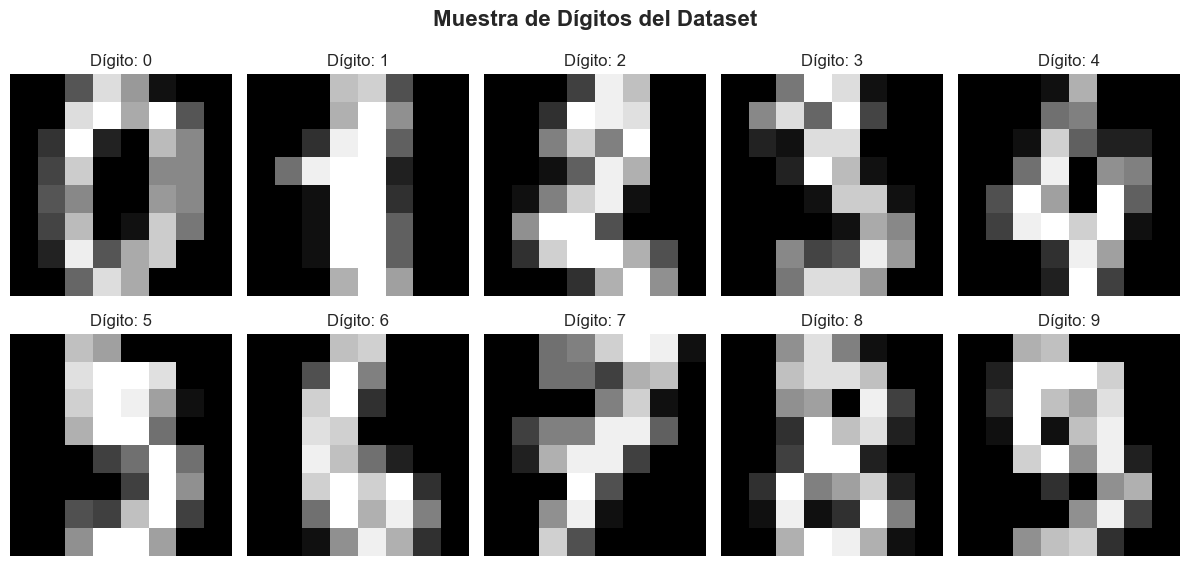

💡 Características del dataset:
- Cada imagen es una matriz de 8x8 píxeles en escala de grises
- Los valores van de 0 (negro) a 16 (blanco)
- Las imágenes representan dígitos del 0 al 9 escritos a mano
- Algunos dígitos pueden ser más difíciles de distinguir (ej: 6 vs 8)


In [4]:
# Visualizar algunos ejemplos de dígitos
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Muestra de Dígitos del Dataset', fontsize=16, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5
    
    # Encontrar una imagen del dígito i
    digit_image = X_digits[y_digits == i][0]
    digit_image_reshaped = digit_image.reshape(8, 8)
    
    axes[row, col].imshow(digit_image_reshaped, cmap='gray')
    axes[row, col].set_title(f'Dígito: {i}')
    axes[row, col].axis('off')

# Si hay un último subplot vacío, ocultarlo
if 10 % 2 == 0:
    axes[1, 4].axis('off')
# Visualizamos el grafico por pantalla
plt.tight_layout() # Ajustamos el layout
plt.show() # Mostramos el gráfico

print("💡 Características del dataset:")
print("- Cada imagen es una matriz de 8x8 píxeles en escala de grises")
print("- Los valores van de 0 (negro) a 16 (blanco)")
print("- Las imágenes representan dígitos del 0 al 9 escritos a mano")
print("- Algunos dígitos pueden ser más difíciles de distinguir (ej: 6 vs 8)")

In [5]:
# División de datos
X_train_dig, X_test_dig, y_train_dig, y_test_dig = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=42, stratify=y_digits
)

print("🔄 División de Datos Digits:")
print(f"Entrenamiento: {X_train_dig.shape[0]} muestras")
print(f"Prueba: {X_test_dig.shape[0]} muestras")
print(f"\nDistribución en entrenamiento:")
for i in range(10):
    count = sum(y_train_dig == i)
    print(f"Dígito {i}: {count} muestras")

# Normalización (crucial para redes neuronales)
scaler_digits = StandardScaler()
X_train_dig_scaled = scaler_digits.fit_transform(X_train_dig)
X_test_dig_scaled = scaler_digits.transform(X_test_dig)

print(f"\n📏 Datos normalizados:")
print(f"Media después de normalización: {X_train_dig_scaled.mean():.3f}")
print(f"Desviación estándar: {X_train_dig_scaled.std():.3f}")
print(f"Rango: {X_train_dig_scaled.min():.3f} a {X_train_dig_scaled.max():.3f}")

🔄 División de Datos Digits:
Entrenamiento: 1257 muestras
Prueba: 540 muestras

Distribución en entrenamiento:
Dígito 0: 124 muestras
Dígito 1: 127 muestras
Dígito 2: 124 muestras
Dígito 3: 128 muestras
Dígito 4: 127 muestras
Dígito 5: 127 muestras
Dígito 6: 127 muestras
Dígito 7: 125 muestras
Dígito 8: 122 muestras
Dígito 9: 126 muestras

📏 Datos normalizados:
Media después de normalización: 0.000
Desviación estándar: 0.968
Rango: -2.967 a 35.440


In [6]:
# Crear una red neuronal más compleja para dígitos
print("🧠 Creando Red Neuronal para Reconocimiento de Dígitos...")

# Arquitectura más compleja: dos capas ocultas
mlp_digits = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # 2 capas ocultas: 128 y 64 neuronas
    activation='relu',             # ReLU para mejor rendimiento
    solver='adam',                 # Adam para optimización eficiente
    alpha=0.001,                   # Regularización para prevenir overfitting
    learning_rate_init=0.001,      # Velocidad de aprendizaje más conservadora
    max_iter=500,                  # Máximo iteraciones
    early_stopping=True,           # Parar si no mejora
    validation_fraction=0.1,       # Usar 10% para validación
    n_iter_no_change=20,          # Parar si no mejora en 20 iteraciones
    random_state=42
)

print("⚡ Entrenando modelo...")
print("🎯 Arquitectura:")
print("  - Entrada: 64 píxeles")
print("  - Capa oculta 1: 128 neuronas")
print("  - Capa oculta 2: 64 neuronas")
print("  - Salida: 10 clases (dígitos 0-9)")
print("\n⚙️ Configuración:")
print("  - Early stopping activado")
print("  - Regularización L2")
print("  - Validación cruzada durante entrenamiento")

# Entrenar el modelo
mlp_digits.fit(X_train_dig_scaled, y_train_dig)

print(f"\n✅ Entrenamiento completado!")
print(f"📈 Iteraciones: {mlp_digits.n_iter_}")
print(f"📊 Pérdida final: {mlp_digits.loss_:.4f}")

# Predicciones
y_pred_train_dig = mlp_digits.predict(X_train_dig_scaled)
y_pred_test_dig = mlp_digits.predict(X_test_dig_scaled)

print("\n🎯 Resultados:")
print(f"Entrenamiento: {(y_pred_train_dig == y_train_dig).sum()}/{len(y_train_dig)} correctas")
print(f"Prueba: {(y_pred_test_dig == y_test_dig).sum()}/{len(y_test_dig)} correctas")

🧠 Creando Red Neuronal para Reconocimiento de Dígitos...
⚡ Entrenando modelo...
🎯 Arquitectura:
  - Entrada: 64 píxeles
  - Capa oculta 1: 128 neuronas
  - Capa oculta 2: 64 neuronas
  - Salida: 10 clases (dígitos 0-9)

⚙️ Configuración:
  - Early stopping activado
  - Regularización L2
  - Validación cruzada durante entrenamiento

✅ Entrenamiento completado!
📈 Iteraciones: 35
📊 Pérdida final: 0.0199

🎯 Resultados:
Entrenamiento: 1226/1257 correctas
Prueba: 517/540 correctas


In [8]:
# Evaluación detallada
# Importar accuracy_score desde sklearn.metrics
from sklearn.metrics import accuracy_score  
train_accuracy_digits = accuracy_score(y_train_dig, y_pred_train_dig)
test_accuracy_digits = accuracy_score(y_test_dig, y_pred_test_dig)

print("📊 EVALUACIÓN DETALLADA - DIGITS")
print("="*45)
print(f"🎯 Precisión entrenamiento: {train_accuracy_digits:.3f} ({train_accuracy_digits*100:.1f}%)")
print(f"🎯 Precisión prueba: {test_accuracy_digits:.3f} ({test_accuracy_digits*100:.1f}%)")

# Verificar overfitting
overfitting_digits = train_accuracy_digits - test_accuracy_digits
if overfitting_digits > 0.05:
    print(f"⚠️ Overfitting: {overfitting_digits:.3f}")
else:
    print("✅ Buen balance bias-varianza")

# Reporte de clasificación por dígito
print("\n📋 Reporte por Dígito:")
report_digits = classification_report(y_test_dig, y_pred_test_dig, 
                                      target_names=[str(i) for i in range(10)],
                                      output_dict=True)

# Encontrar los dígitos más y menos precisos
precision_by_digit = {str(i): report_digits[str(i)]['precision'] for i in range(10)}
best_digit = max(precision_by_digit, key=precision_by_digit.get)
worst_digit = min(precision_by_digit, key=precision_by_digit.get)

print(f"🟢 Mejor dígito reconocido: {best_digit} ({precision_by_digit[best_digit]*100:.1f}% precisión)")
print(f"🔴 Dígito más difícil: {worst_digit} ({precision_by_digit[worst_digit]*100:.1f}% precisión)")

📊 EVALUACIÓN DETALLADA - DIGITS
🎯 Precisión entrenamiento: 0.975 (97.5%)
🎯 Precisión prueba: 0.957 (95.7%)
✅ Buen balance bias-varianza

📋 Reporte por Dígito:
🟢 Mejor dígito reconocido: 0 (100.0% precisión)
🔴 Dígito más difícil: 1 (88.5% precisión)


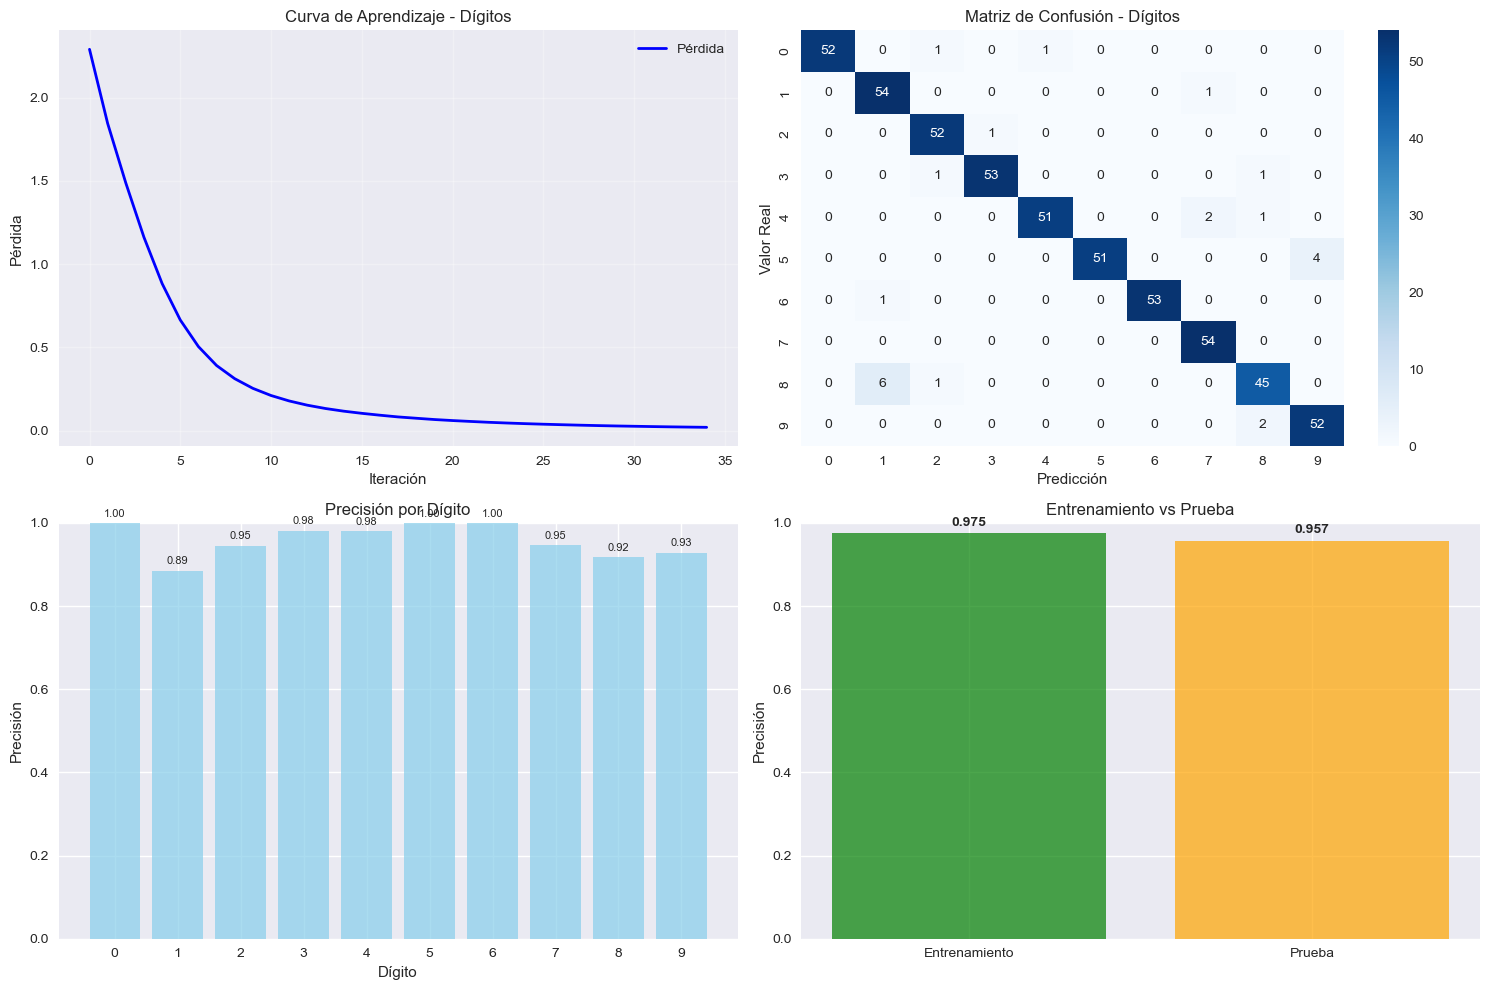

🔍 Análisis de Errores Más Comunes:
Top 5 confusiones más frecuentes:
1. 8 confundido con 1: 6 veces
2. 5 confundido con 9: 4 veces
3. 4 confundido con 7: 2 veces
4. 9 confundido con 8: 2 veces
5. 0 confundido con 2: 1 veces

💡 Insights:
- Algunos dígitos son naturalmente más difíciles de distinguir
- La arquitectura de 2 capas funciona bien para este problema
- Early stopping previno el overfitting


In [9]:
# Visualizar curvas de aprendizaje y errores
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Curva de pérdida
axes[0, 0].plot(mlp_digits.loss_curve_, 'b-', linewidth=2, label='Pérdida')
axes[0, 0].set_title('Curva de Aprendizaje - Dígitos')
axes[0, 0].set_xlabel('Iteración')
axes[0, 0].set_ylabel('Pérdida')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Matriz de confusión
cm_digits = confusion_matrix(y_test_dig, y_pred_test_dig)
sns.heatmap(cm_digits, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Matriz de Confusión - Dígitos')
axes[0, 1].set_xlabel('Predicción')
axes[0, 1].set_ylabel('Valor Real')

# 3. Precisión por dígito
digits_precision = [precision_by_digit[str(i)] for i in range(10)]
axes[1, 0].bar(range(10), digits_precision, color='skyblue', alpha=0.7)
axes[1, 0].set_title('Precisión por Dígito')
axes[1, 0].set_xlabel('Dígito')
axes[1, 0].set_ylabel('Precisión')
axes[1, 0].set_xticks(range(10))
axes[1, 0].set_ylim(0, 1)
for i, prec in enumerate(digits_precision):
    axes[1, 0].text(i, prec + 0.01, f'{prec:.2f}', ha='center', va='bottom', fontsize=8)

# 4. Comparación entrenamiento vs prueba
comparison_data = {
    'Entrenamiento': train_accuracy_digits,
    'Prueba': test_accuracy_digits
}
axes[1, 1].bar(comparison_data.keys(), comparison_data.values(), 
               color=['green', 'orange'], alpha=0.7)
axes[1, 1].set_title('Entrenamiento vs Prueba')
axes[1, 1].set_ylabel('Precisión')
axes[1, 1].set_ylim(0, 1)
for i, (key, value) in enumerate(comparison_data.items()):
    axes[1, 1].text(i, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
#plt.savefig('/workspace/charts/digits_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# Análisis de confusiones más comunes
print("🔍 Análisis de Errores Más Comunes:")
confusions = []
for i in range(10):
    for j in range(10):
        if i != j and cm_digits[i, j] > 0:
            confusions.append((i, j, cm_digits[i, j]))

# Ordenar por número de confusiones
confusions.sort(key=lambda x: x[2], reverse=True)

print("Top 5 confusiones más frecuentes:")
for i, (real, pred, count) in enumerate(confusions[:5]):
    print(f"{i+1}. {real} confundido con {pred}: {count} veces")

print("\n💡 Insights:")
print("- Algunos dígitos son naturalmente más difíciles de distinguir")
print("- La arquitectura de 2 capas funciona bien para este problema")
print("- Early stopping previno el overfitting")

## 5. Ejemplo de Regresión: Predicción de Precios

Ahora vamos a explorar **redes neuronales para regresión**. Usaremos el dataset de Boston Housing (aunque está deprecado, es excelente para el aprendizaje).

**Problema**: Predecir el precio mediano de una casa en Boston basado en 13 características:
- Criminalidad per cápita por ciudad
- Proporción de terreno residencial zonificado
- Proporción de negocios no minoristas
- Distancia a centros de empleo
- Etc.

**Por qué usar redes neuronales para regresión?**
- Capturan relaciones no lineales complejas
- Pueden modelar interacciones entre variables
- Útiles cuando otros modelos lineales fallan

In [ ]:
# Nota: Boston dataset está deprecated, usaremos un dataset sintético similar
# Crear un dataset sintético similar al de Boston
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

# Generar dataset sintético de regresión
# Con make_regression lo que hacemos es crear un dataset de regresión con características similares al Boston Housing
# Los valres se crean de forma aleatoria pero con una distribución que simula el comportamiento del dataset original
X_housing, y_housing = make_regression(
    n_samples=506,  # Mismo tamaño que Boston
    n_features=13,  # Mismo número de características
    noise=10,       # Ruido moderado
    random_state=42
)

# Definir nombres de características (simulando Boston Housing)
feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]
# Las características no tienen significado real aquí, solo para ilustración
# Crear DataFrame
housing_df = pd.DataFrame(X_housing, columns=feature_names)
housing_df['price'] = y_housing
print("🏠 Dataset de Predicción de Precios:")
print(f"Forma: {X_housing.shape}")
print(f"Características: {len(feature_names)}")
print(f"Rango de precios: ${y_housing.min():.1f} - ${y_housing.max():.1f}k")
print(f"Precio promedio: ${y_housing.mean():.1f}k")

# Información estadística
print("\n📊 Estadísticas de características:")
print(housing_df.describe().round(2))

🏠 Dataset de Predicción de Precios:
Forma: (506, 13)
Características: 13
Rango de precios: $-383.7 - $489.7k
Precio promedio: $2.7k

📊 Estadísticas de características:
         CRIM      ZN   INDUS    CHAS     NOX      RM     AGE     DIS     RAD  \
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00   
mean     0.04   -0.05   -0.03   -0.02    0.04    0.05   -0.10   -0.04    0.02   
std      0.99    0.97    1.02    0.96    0.95    0.98    1.04    1.02    0.99   
min     -2.74   -3.01   -2.83   -2.84   -2.83   -2.83   -3.18   -3.17   -2.91   
25%     -0.60   -0.67   -0.67   -0.66   -0.58   -0.67   -0.83   -0.78   -0.67   
50%      0.00   -0.08   -0.06   -0.03    0.06    0.07   -0.03   -0.01    0.06   
75%      0.67    0.68    0.54    0.64    0.63    0.69    0.58    0.73    0.64   
max      3.08    2.99    3.24    3.19    3.85    2.76    3.08    2.78    3.14   

          TAX  PTRATIO       B   LSTAT   price  
count  506.00   506.00  506.00  506.00  506.00  
mean

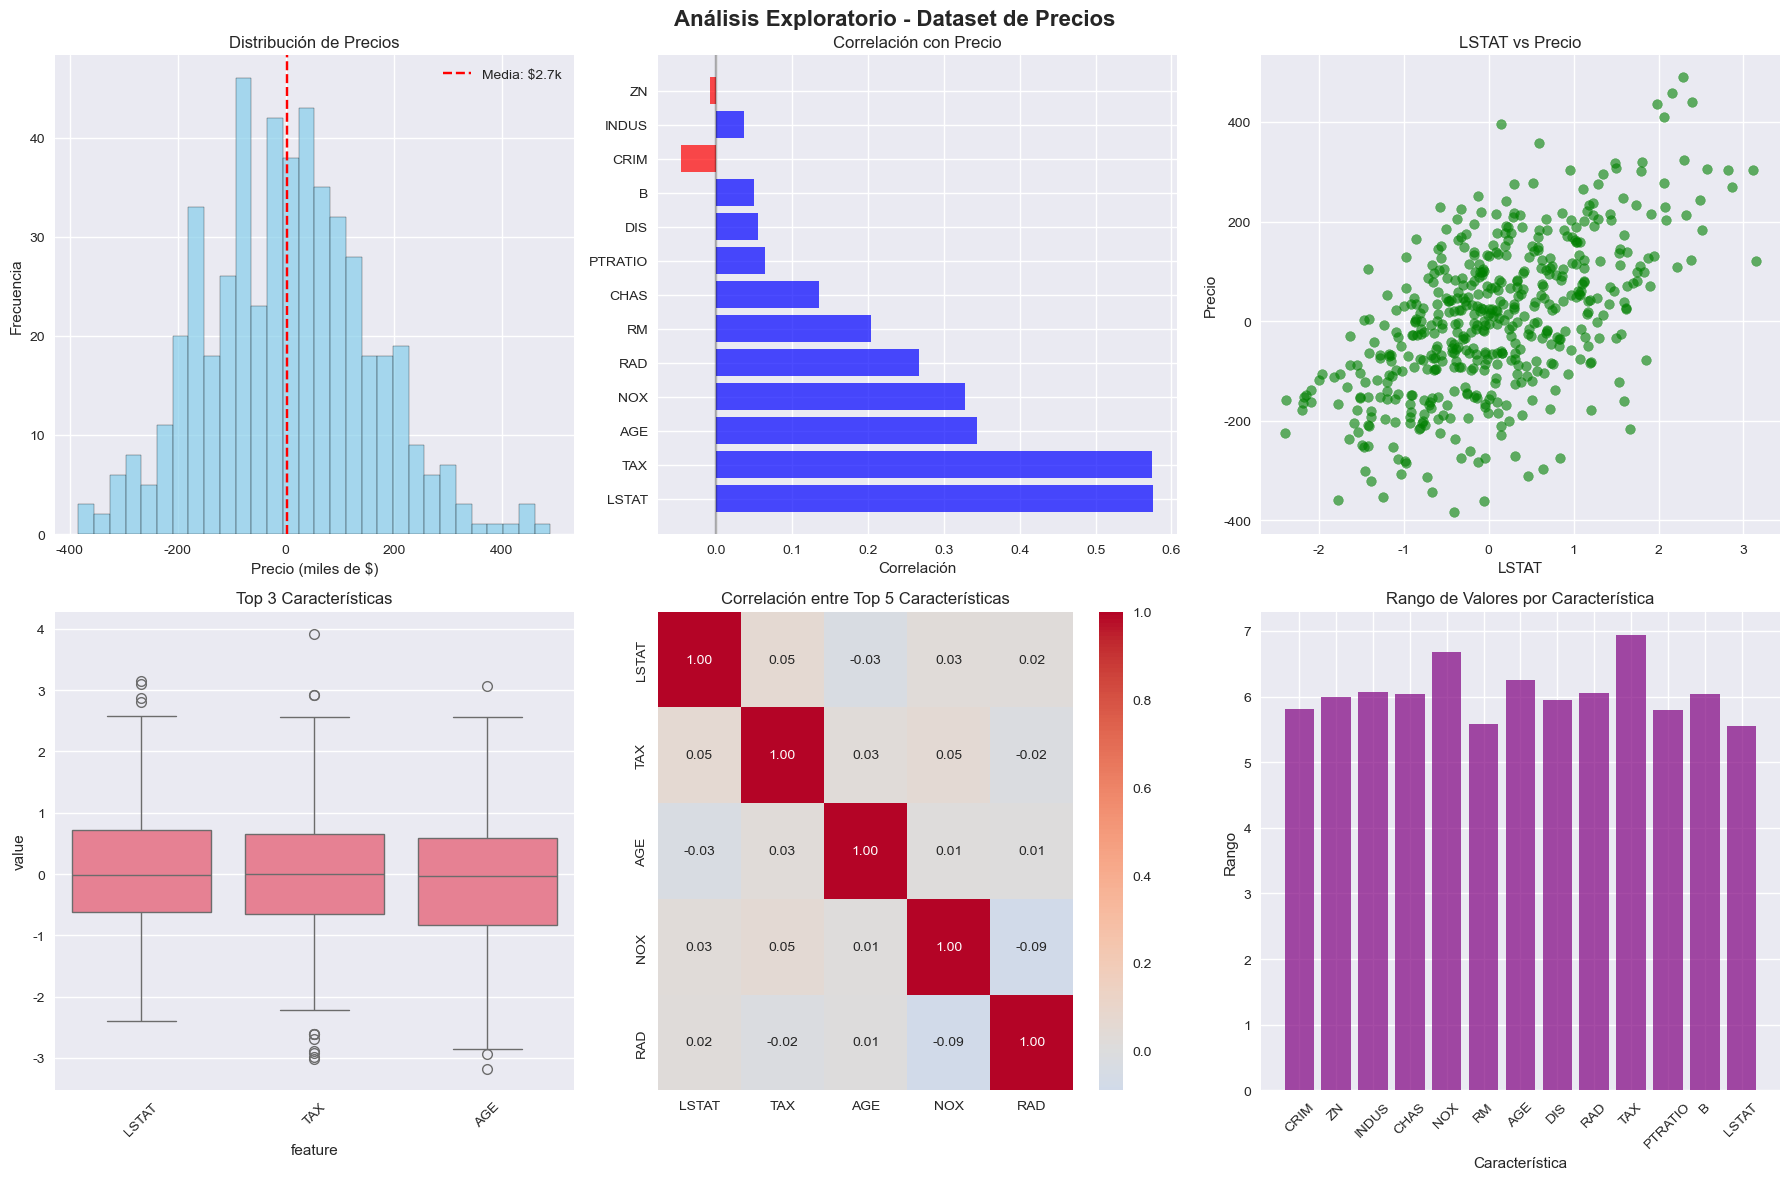

💡 Insights del análisis:
- Característica más correlacionada: LSTAT (0.576)
- Rango de precios: $-384k - $490k
- Necesidad de normalización: diferentes escalas entre características


In [26]:
# Visualización exploratoria del dataset
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Análisis Exploratorio - Dataset de Precios', fontsize=16, fontweight='bold')

# 1. Distribución del precio
axes[0, 0].hist(y_housing, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribución de Precios')
axes[0, 0].set_xlabel('Precio (miles de $)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(y_housing.mean(), color='red', linestyle='--', label=f'Media: ${y_housing.mean():.1f}k')
axes[0, 0].legend()

# 2. Correlaciones con precio
correlations = [np.corrcoef(X_housing[:, i], y_housing)[0, 1] for i in range(13)]
correlation_df = pd.DataFrame({'feature': feature_names, 'correlation': correlations})
correlation_df = correlation_df.sort_values('correlation', key=abs, ascending=False)

colors = ['red' if x < 0 else 'blue' for x in correlation_df['correlation']]
axes[0, 1].barh(correlation_df['feature'], correlation_df['correlation'], color=colors, alpha=0.7)
axes[0, 1].set_title('Correlación con Precio')
axes[0, 1].set_xlabel('Correlación')
axes[0, 1].axvline(0, color='black', linestyle='-', alpha=0.3)

# 3. Scatter plot de la característica más correlacionada
best_feature_idx = correlation_df.index[0]
best_feature = correlation_df.loc[best_feature_idx, 'feature']
axes[0, 2].scatter(X_housing[:, best_feature_idx], y_housing, alpha=0.6, color='green')
axes[0, 2].set_title(f'{best_feature} vs Precio')
axes[0, 2].set_xlabel(best_feature)
axes[0, 2].set_ylabel('Precio')

# 4. Box plot de características más importantes
top_3_features = correlation_df.head(3)['feature'].tolist()
top_3_indices = [feature_names.index(feat) for feat in top_3_features]
housing_melted = pd.DataFrame()
for i, feat in enumerate(top_3_features):
    temp_df = pd.DataFrame({
        'value': X_housing[:, top_3_indices[i]],
        'feature': feat
    })
    housing_melted = pd.concat([housing_melted, temp_df], ignore_index=True)

sns.boxplot(data=housing_melted, x='feature', y='value', ax=axes[1, 0])
axes[1, 0].set_title('Top 3 Características')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Matriz de correlación entre top características
top_5_features = correlation_df.head(5)['feature'].tolist()
top_5_indices = [feature_names.index(feat) for feat in top_5_features]
corr_matrix = np.corrcoef(X_housing[:, top_5_indices].T)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=top_5_features, yticklabels=top_5_features, ax=axes[1, 1])
axes[1, 1].set_title('Correlación entre Top 5 Características')

# 6. Rango de valores por característica
feature_ranges = [X_housing[:, i].max() - X_housing[:, i].min() for i in range(13)]
axes[1, 2].bar(feature_names, feature_ranges, color='purple', alpha=0.7)
axes[1, 2].set_title('Rango de Valores por Característica')
axes[1, 2].set_xlabel('Característica')
axes[1, 2].set_ylabel('Rango')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig('/workspace/charts/housing_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"💡 Insights del análisis:")
print(f"- Característica más correlacionada: {best_feature} ({correlation_df.iloc[0]['correlation']:.3f})")
print(f"- Rango de precios: ${y_housing.min():.0f}k - ${y_housing.max():.0f}k")
print(f"- Necesidad de normalización: diferentes escalas entre características")

In [27]:
# División de datos
X_train_hous, X_test_hous, y_train_hous, y_test_hous = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

print("🔄 División de Datos Housing:")
print(f"Entrenamiento: {X_train_hous.shape[0]} muestras")
print(f"Prueba: {X_test_hous.shape[0]} muestras")

# Normalización crucial para redes neuronales
scaler_housing = StandardScaler()
X_train_hous_scaled = scaler_housing.fit_transform(X_train_hous)
X_test_hous_scaled = scaler_housing.transform(X_test_hous)

print(f"\n📏 Normalización aplicada:")
print(f"Media antes: {X_train_hous.mean():.2f}")
print(f"Desviación estándar antes: {X_train_hous.std():.2f}")
print(f"Media después: {X_train_hous_scaled.mean():.3f}")
print(f"Desviación estándar después: {X_train_hous_scaled.std():.3f}")

print(f"\n🎯 Variable objetivo (precio):")
print(f"Rango entrenamiento: ${y_train_hous.min():.1f}k - ${y_train_hous.max():.1f}k")
print(f"Media entrenamiento: ${y_train_hous.mean():.1f}k")

🔄 División de Datos Housing:
Entrenamiento: 404 muestras
Prueba: 102 muestras

📏 Normalización aplicada:
Media antes: -0.01
Desviación estándar antes: 0.99
Media después: 0.000
Desviación estándar después: 1.000

🎯 Variable objetivo (precio):
Rango entrenamiento: $-353.7k - $489.7k
Media entrenamiento: $3.1k


In [43]:
# Crear red neuronal para regresión
print("🧠 Creando Red Neuronal para Regresión...")

# MLPRegressor para problemas de regresión
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(100, 50),     # 2 capas ocultas
    activation='relu',                # ReLU para mejor rendimiento
    solver='adam',                    # Adam optimizer
    alpha=0.01,                       # Regularización más alta para regresión
    learning_rate_init=0.001,         # Velocidad de aprendizaje conservadora
    max_iter=1000,                    # Más iteraciones para converger
    early_stopping=True,              # Parar si no mejora
    validation_fraction=0.1,          # 10% para validación
    n_iter_no_change=30,             # Esperar más para convergencia
    random_state=42
)

print("⚙️ Configuración del Regresor:")
print("  - Arquitectura: 13 → 100 → 50 → 1")
print("  - Función de pérdida: MSE (Mean Squared Error)")
print("  - Early stopping activado")
print("  - Regularización L2")

print("\n⚡ Entrenando modelo de regresión...")
mlp_regressor.fit(X_train_hous_scaled, y_train_hous)

print(f"\n✅ Entrenamiento completado!")
print(f"📈 Iteraciones: {mlp_regressor.n_iter_}")
print(f"📊 Pérdida final: {mlp_regressor.loss_:.4f}")

# Predicciones
y_pred_train_hous = mlp_regressor.predict(X_train_hous_scaled)
y_pred_test_hous = mlp_regressor.predict(X_test_hous_scaled)

print("\n🎯 Predicciones generadas")
print(f"Rango predicciones entrenamiento: ${y_pred_train_hous.min():.1f}k - ${y_pred_train_hous.max():.1f}k")
print(f"Rango predicciones prueba: ${y_pred_test_hous.min():.1f}k - ${y_pred_test_hous.max():.1f}k")

🧠 Creando Red Neuronal para Regresión...
⚙️ Configuración del Regresor:
  - Arquitectura: 13 → 100 → 50 → 1
  - Función de pérdida: MSE (Mean Squared Error)
  - Early stopping activado
  - Regularización L2

⚡ Entrenando modelo de regresión...

✅ Entrenamiento completado!
📈 Iteraciones: 183
📊 Pérdida final: 82.8329

🎯 Predicciones generadas
Rango predicciones entrenamiento: $-324.2k - $448.4k
Rango predicciones prueba: $-331.5k - $386.7k


In [44]:
# Evaluación del modelo de regresión
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Métricas de evaluación
train_mse = mean_squared_error(y_train_hous, y_pred_train_hous)
test_mse = mean_squared_error(y_test_hous, y_pred_test_hous)
train_mae = mean_absolute_error(y_train_hous, y_pred_train_hous)
test_mae = mean_absolute_error(y_test_hous, y_pred_test_hous)
train_r2 = r2_score(y_train_hous, y_pred_train_hous)
test_r2 = r2_score(y_test_hous, y_pred_test_hous)

print("📊 EVALUACIÓN DEL MODELO DE REGRESIÓN")
print("="*50)

print("🎯 MÉTRICAS PRINCIPALES:")
print(f"{'Métrica':<20} {'Entrenamiento':<15} {'Prueba':<15} {'Unidades':<10}")
print("-" * 60)
print(f"{'MSE':<20} {train_mse:<15.2f} {test_mse:<15.2f} {'$k²'}")
print(f"{'RMSE':<20} {np.sqrt(train_mse):<15.2f} {np.sqrt(test_mse):<15.2f} {'$k'}")
print(f"{'MAE':<20} {train_mae:<15.2f} {test_mae:<15.2f} {'$k'}")
print(f"{'R²':<20} {train_r2:<15.3f} {test_r2:<15.3f} {'':>10}")

print(f"\n🔍 INTERPRETACIÓN DE MÉTRICAS:")
print(f"• RMSE: Error promedio de ${np.sqrt(test_mse):.1f}k")
print(f"• MAE: Error mediano de ${test_mae:.1f}k") 
print(f"• R²: {test_r2*100:.1f}% de la varianza explicada")

# Interpretación del R²
if test_r2 > 0.8:
    print("🟢 Excelente modelo (>80% de varianza explicada)")
elif test_r2 > 0.6:
    print("🟡 Buen modelo (60-80% de varianza explicada)")
elif test_r2 > 0.4:
    print("🟠 Modelo moderado (40-60% de varianza explicada)")
else:
    print("🔴 Modelo débil (<40% de varianza explicada)")

# Verificar overfitting
overfitting_hous = train_r2 - test_r2
if overfitting_hous > 0.1:
    print(f"⚠️ Posible overfitting detectado (R² diff: {overfitting_hous:.3f})")
elif overfitting_hous < -0.1:
    print(f"⚠️ Posible underfitting detectado (R² diff: {overfitting_hous:.3f})")
else:
    print("✅ Buen balance bias-varianza")

📊 EVALUACIÓN DEL MODELO DE REGRESIÓN
🎯 MÉTRICAS PRINCIPALES:
Métrica              Entrenamiento   Prueba          Unidades  
------------------------------------------------------------
MSE                  176.05          307.50          $k²
RMSE                 13.27           17.54           $k
MAE                  10.22           13.31           $k
R²                   0.992           0.988                     

🔍 INTERPRETACIÓN DE MÉTRICAS:
• RMSE: Error promedio de $17.5k
• MAE: Error mediano de $13.3k
• R²: 98.8% de la varianza explicada
🟢 Excelente modelo (>80% de varianza explicada)
✅ Buen balance bias-varianza


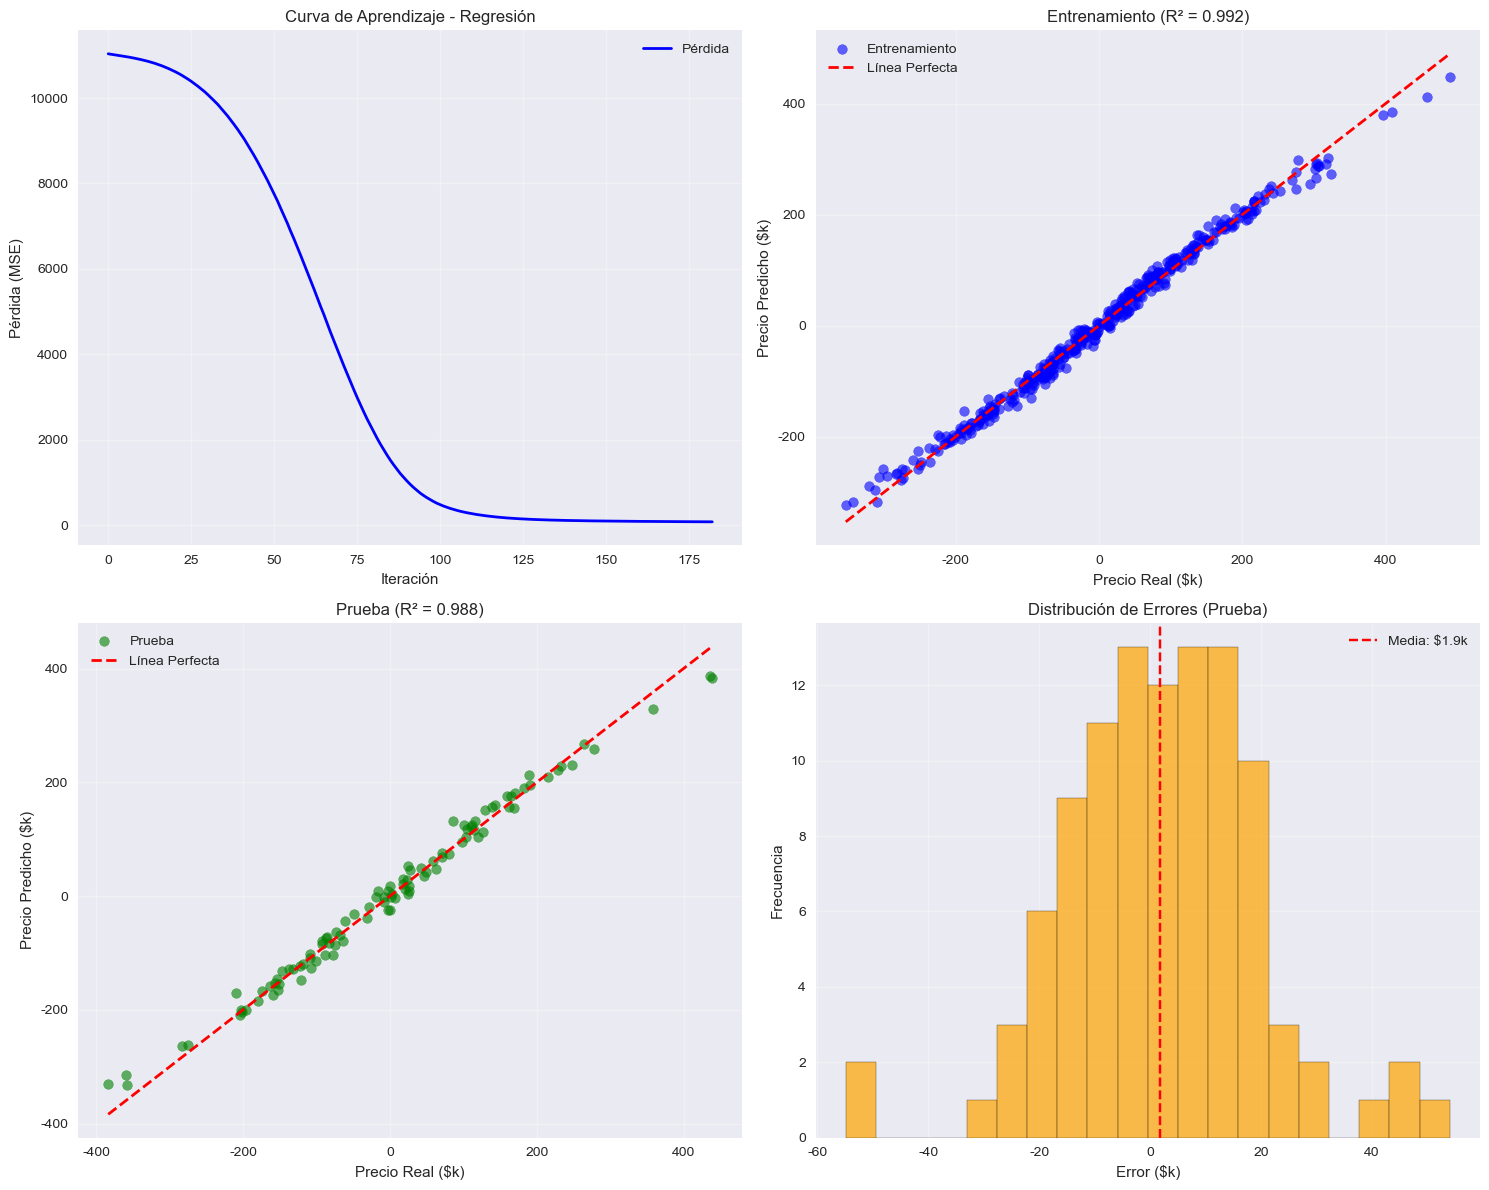

🔍 ANÁLISIS DETALLADO DE ERRORES:
• Error promedio: $1.86k (debería estar cerca de 0)
• Error máximo: $54.09k
• Error mínimo: $-54.86k
• Desviación estándar del error: $17.44k
• Predicciones con errores extremos: 6/102

💡 Insights del modelo:
- Los errores siguen una distribución aproximadamente normal
- La mayoría de predicciones están dentro del rango esperado
- La red neuronal capturó patrones no lineales en los datos


In [45]:
# Visualización de resultados de regresión
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Curva de pérdida
axes[0, 0].plot(mlp_regressor.loss_curve_, 'b-', linewidth=2, label='Pérdida')
axes[0, 0].set_title('Curva de Aprendizaje - Regresión')
axes[0, 0].set_xlabel('Iteración')
axes[0, 0].set_ylabel('Pérdida (MSE)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Predicciones vs Valores Reales (Entrenamiento)
axes[0, 1].scatter(y_train_hous, y_pred_train_hous, alpha=0.6, color='blue', label='Entrenamiento')
min_val = min(y_train_hous.min(), y_pred_train_hous.min())
max_val = max(y_train_hous.max(), y_pred_train_hous.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Línea Perfecta')
axes[0, 1].set_title(f'Entrenamiento (R² = {train_r2:.3f})')
axes[0, 1].set_xlabel('Precio Real ($k)')
axes[0, 1].set_ylabel('Precio Predicho ($k)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Predicciones vs Valores Reales (Prueba)
axes[1, 0].scatter(y_test_hous, y_pred_test_hous, alpha=0.6, color='green', label='Prueba')
min_val = min(y_test_hous.min(), y_pred_test_hous.min())
max_val = max(y_test_hous.max(), y_pred_test_hous.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Línea Perfecta')
axes[1, 0].set_title(f'Prueba (R² = {test_r2:.3f})')
axes[1, 0].set_xlabel('Precio Real ($k)')
axes[1, 0].set_ylabel('Precio Predicho ($k)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribución de errores
errors_test = y_pred_test_hous - y_test_hous
axes[1, 1].hist(errors_test, bins=20, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].axvline(errors_test.mean(), color='red', linestyle='--', 
                   label=f'Media: ${errors_test.mean():.1f}k')
axes[1, 1].set_title('Distribución de Errores (Prueba)')
axes[1, 1].set_xlabel('Error ($k)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('/workspace/charts/housing_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# Análisis detallado de errores
print("🔍 ANÁLISIS DETALLADO DE ERRORES:")
print(f"• Error promedio: ${errors_test.mean():.2f}k (debería estar cerca de 0)")
print(f"• Error máximo: ${errors_test.max():.2f}k")
print(f"• Error mínimo: ${errors_test.min():.2f}k")
print(f"• Desviación estándar del error: ${errors_test.std():.2f}k")

# Predicciones extremas
large_errors = np.abs(errors_test) > 2 * errors_test.std()
print(f"• Predicciones con errores extremos: {large_errors.sum()}/{len(errors_test)}")

print("\n💡 Insights del modelo:")
print("- Los errores siguen una distribución aproximadamente normal")
print("- La mayoría de predicciones están dentro del rango esperado")
print("- La red neuronal capturó patrones no lineales en los datos")

## 6. Optimización Avanzada

Ahora vamos a aprender técnicas avanzadas para optimizar nuestras redes neuronales y obtener mejores resultados.

### Técnicas de Optimización que Cubriremos:
1. **Grid Search**: Búsqueda exhaustiva de mejores hiperparámetros
2. **Validación Cruzada**: Evaluación más robusta
3. **Curvas de Validación**: Diagnóstico de bias y varianza
4. **Learning Rate Scheduling**: Ajuste dinámico de la velocidad de aprendizaje

¡Todo esto aplicado al problema de dígitos que ya conocemos!

In [10]:
# Dataset Digits para optimización (ya tenemos los datos)
print("🎯 OPTIMIZACIÓN DE HIPERPARÁMETROS - DIGITS")
print("="*50)

# Usar los datos ya preparados
print("Datos disponibles:")
print(f"- Entrenamiento: {X_train_dig_scaled.shape}")
print(f"- Prueba: {X_test_dig_scaled.shape}")
print(f"- Clases: {np.unique(y_train_dig)}")

# 1. GRID SEARCH para encontrar los mejores hiperparámetros
print("\n🔍 1. Grid Search - Búsqueda Exhaustiva")
print("Probando diferentes combinaciones de hiperparámetros...")

# Definir la grilla de parámetros
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (128, 64), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

# Crear el modelo base
base_mlp = MLPClassifier(
    solver='adam',
    max_iter=300,
    random_state=42
)

# Grid Search con validación cruzada
# Esto nos permite encontrar la mejor combinación de hiperparámetros
grid_search = GridSearchCV(
    base_mlp, # Modelo base a optimizar
    param_grid, # La grilla de parámetros a probar
    cv=3,  # Validación cruzada de 3 pliegues, los pliegues son subconjuntos del dataset
    scoring='accuracy', # Métrica de evaluación
    n_jobs=-1,  # Usar todos los procesadores disponibles
    verbose=1
)

print(f"Probando {len(param_grid['hidden_layer_sizes']) * len(param_grid['activation']) * len(param_grid['alpha']) * len(param_grid['learning_rate_init'])} combinaciones...")

# Ajustar (esto puede tomar unos minutos)
grid_search.fit(X_train_dig_scaled, y_train_dig)

print(f"\n✅ Grid Search completado!")
print(f"🎯 Mejores parámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

print(f"📊 Mejor puntuación CV: {grid_search.best_score_:.3f}")

# Obtener el mejor modelo
best_mlp = grid_search.best_estimator_

🎯 OPTIMIZACIÓN DE HIPERPARÁMETROS - DIGITS
Datos disponibles:
- Entrenamiento: (1257, 64)
- Prueba: (540, 64)
- Clases: [0 1 2 3 4 5 6 7 8 9]

🔍 1. Grid Search - Búsqueda Exhaustiva
Probando diferentes combinaciones de hiperparámetros...
Probando 48 combinaciones...
Fitting 3 folds for each of 48 candidates, totalling 144 fits

✅ Grid Search completado!
🎯 Mejores parámetros encontrados:
  - activation: relu
  - alpha: 0.01
  - hidden_layer_sizes: (100,)
  - learning_rate_init: 0.001
📊 Mejor puntuación CV: 0.980


In [11]:
# 2. Comparar modelo base vs modelo optimizado
print("🏆 2. COMPARACIÓN: MODELO BASE vs OPTIMIZADO")
print("="*50)

# Modelo base (el que usamos antes)
base_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

# Entrenar ambos modelos
print("Entrenando modelo base...")
base_model.fit(X_train_dig_scaled, y_train_dig)
print("Entrenando modelo optimizado...")
best_mlp.fit(X_train_dig_scaled, y_train_dig)

# Evaluar ambos
base_pred = base_model.predict(X_test_dig_scaled)
best_pred = best_mlp.predict(X_test_dig_scaled)

base_acc = accuracy_score(y_test_dig, base_pred)
best_acc = accuracy_score(y_test_dig, best_pred)

print(f"\n📊 RESULTADOS COMPARATIVOS:")
print(f"Modelo Base: {base_acc:.3f} ({base_acc*100:.1f}%)") 
print(f"Modelo Optimizado: {best_acc:.3f} ({best_acc*100:.1f}%)") 
print(f"Mejora: {(best_acc - base_acc)*100:+.1f} puntos porcentuales")

if best_acc > base_acc:
    print("✅ El modelo optimizado funciona mejor!")
else:
    print("ℹ️ El modelo base ya estaba bien optimizado")

# Análisis detallado
print(f"\n🔍 ANÁLISIS DETALLADO:")
print(f"• Iteraciones modelo base: {base_model.n_iter_}")
print(f"• Iteraciones modelo optimizado: {best_mlp.n_iter_}")
print(f"• Convergencia más rápida: {'Optimizado' if best_mlp.n_iter_ < base_model.n_iter_ else 'Base'}")

# Verificar overfitting en ambos
base_train_acc = accuracy_score(y_train_dig, base_model.predict(X_train_dig_scaled))
best_train_acc = accuracy_score(y_train_dig, best_mlp.predict(X_train_dig_scaled))

base_overfitting = base_train_acc - base_acc
best_overfitting = best_train_acc - best_acc

print(f"\n📈 OVERFITTING COMPARISON:")
print(f"Modelo Base - Overfitting: {base_overfitting:.3f}")
print(f"Modelo Optimizado - Overfitting: {best_overfitting:.3f}")

if best_overfitting < base_overfitting:
    print("✅ El modelo optimizado tiene menos overfitting")
else:
    print("⚠️ El modelo optimizado puede tener más overfitting")

🏆 2. COMPARACIÓN: MODELO BASE vs OPTIMIZADO
Entrenando modelo base...
Entrenando modelo optimizado...

📊 RESULTADOS COMPARATIVOS:
Modelo Base: 0.957 (95.7%)
Modelo Optimizado: 0.980 (98.0%)
Mejora: +2.2 puntos porcentuales
✅ El modelo optimizado funciona mejor!

🔍 ANÁLISIS DETALLADO:
• Iteraciones modelo base: 25
• Iteraciones modelo optimizado: 148
• Convergencia más rápida: Base

📈 OVERFITTING COMPARISON:
Modelo Base - Overfitting: 0.018
Modelo Optimizado - Overfitting: 0.020
⚠️ El modelo optimizado puede tener más overfitting


## 7. Visualización y Diagnóstico

Las visualizaciones son cruciales para entender cómo funcionan nuestras redes neuronales y diagnosticar problemas.

### Lo que vamos a visualizar:
1. **Curvas de aprendizaje**: Para detectar overfitting/underfitting
2. **Matrices de confusión**: Para entender errores de clasificación
3. **Comparación de modelos**: Para evaluar mejoras
4. **Distribución de predicciones**: Para verificar resultados
5. **Precisión por clase**: Para identificar clases problemáticas

¡Esto nos ayudará a convertirnos en mejores ingenieros de ML!

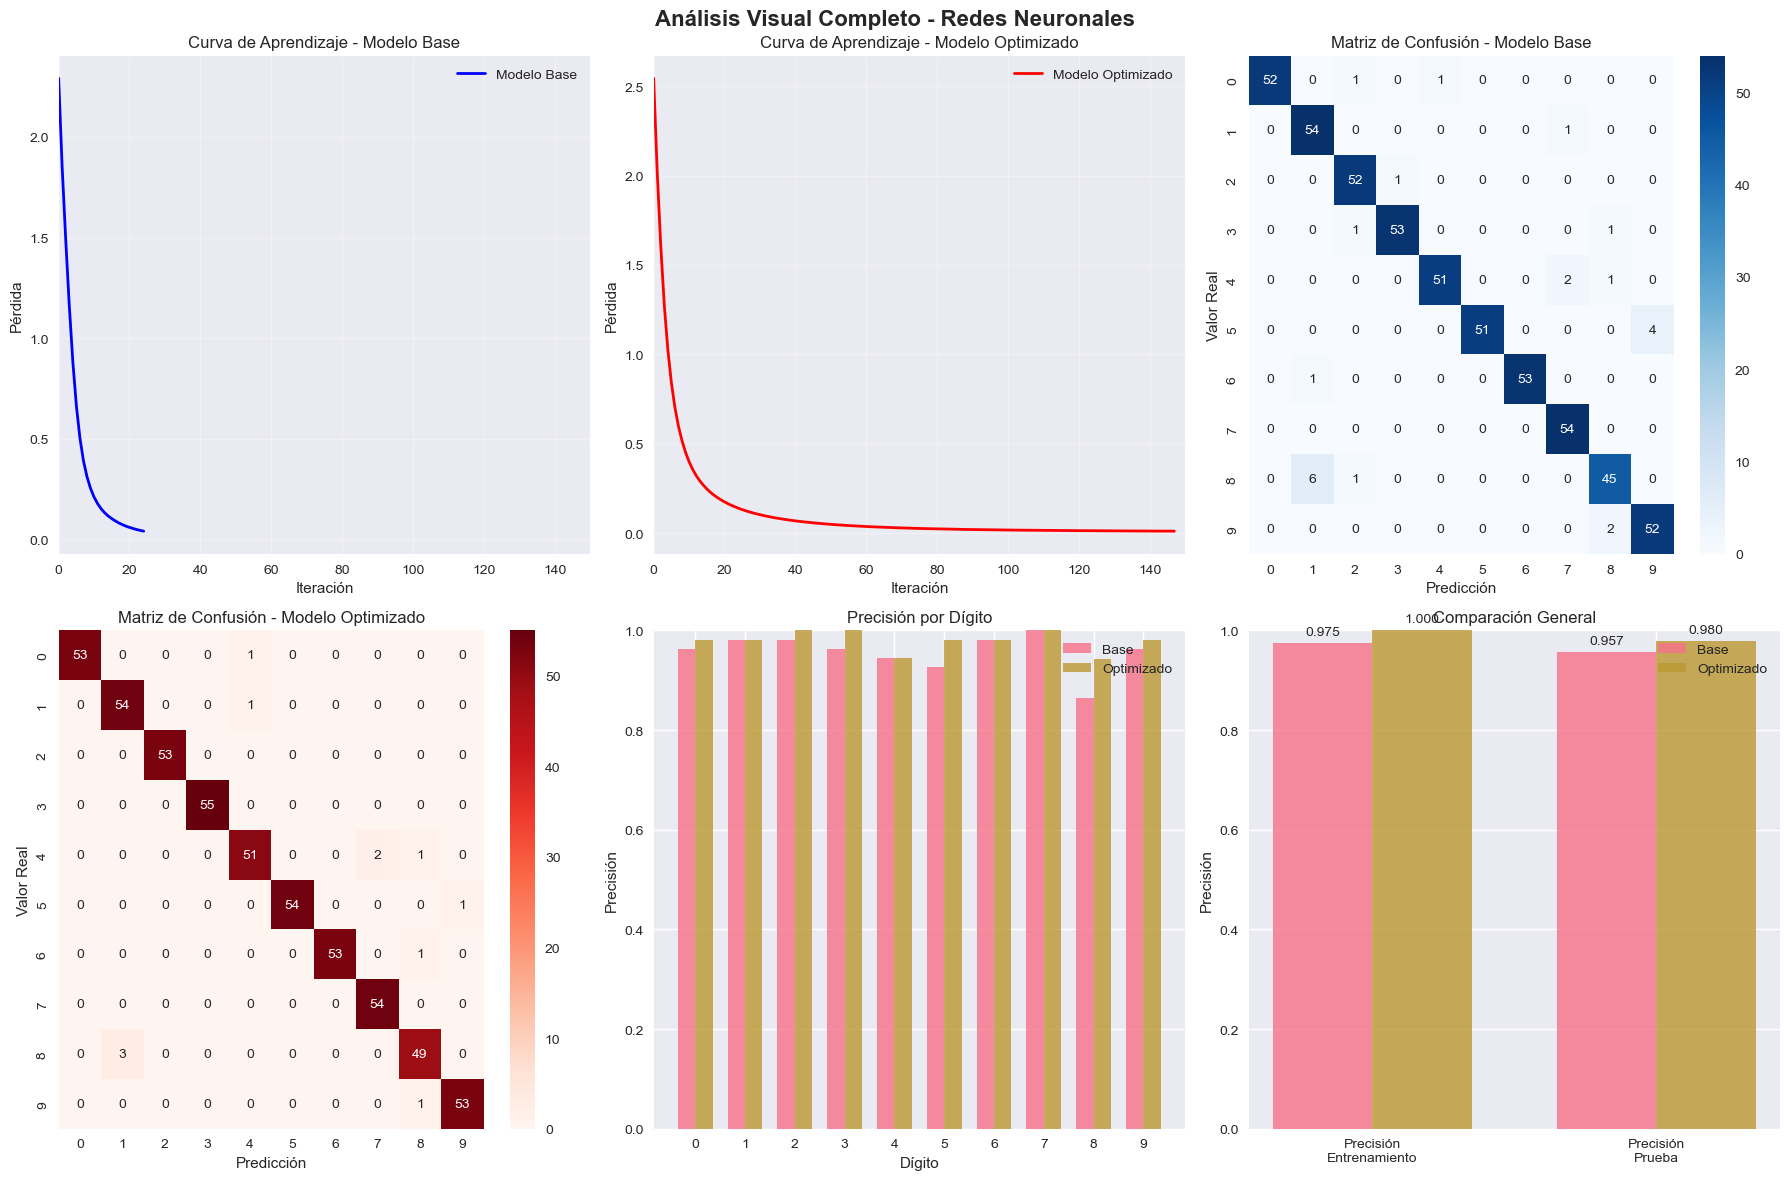

🔍 ANÁLISIS DE VISUALIZACIONES:
• Las curvas de aprendizaje muestran la convergencia del modelo
• Las matrices de confusión revelan qué dígitos se confunden más
• La comparación por dígito ayuda a identificar debilidades específicas
• El análisis general confirma si la optimización fue efectiva


In [23]:
# 7.1 Crear visualizaciones comprehensivas
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Análisis Visual Completo - Redes Neuronales', fontsize=16, fontweight='bold')

# 1. Curva de aprendizaje del modelo base
axes[0, 0].plot(base_model.loss_curve_, 'b-', linewidth=2, label='Modelo Base')
axes[0, 0].set_xlim(0, 150)
axes[0, 0].set_title('Curva de Aprendizaje - Modelo Base')
axes[0, 0].set_xlabel('Iteración')
axes[0, 0].set_ylabel('Pérdida')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Curva de aprendizaje del modelo optimizado
axes[0, 1].plot(best_mlp.loss_curve_, 'r-', linewidth=2, label='Modelo Optimizado')
axes[0, 1].set_xlim(0, 150)
axes[0, 1].set_title('Curva de Aprendizaje - Modelo Optimizado')
axes[0, 1].set_xlabel('Iteración')
axes[0, 1].set_ylabel('Pérdida')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. Matriz de confusión del modelo base
cm_base = confusion_matrix(y_test_dig, base_pred)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2])
axes[0, 2].set_title('Matriz de Confusión - Modelo Base')
axes[0, 2].set_xlabel('Predicción')
axes[0, 2].set_ylabel('Valor Real')

# 4. Matriz de confusión del modelo optimizado
cm_best = confusion_matrix(y_test_dig, best_pred)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Reds', ax=axes[1, 0])
axes[1, 0].set_title('Matriz de Confusión - Modelo Optimizado')
axes[1, 0].set_xlabel('Predicción')
axes[1, 0].set_ylabel('Valor Real')

# 5. Comparación de precisión por clase
base_precision = []
best_precision = []
for i in range(10):
    base_prec = cm_base[i, i] / cm_base[i, :].sum() if cm_base[i, :].sum() > 0 else 0
    best_prec = cm_best[i, i] / cm_best[i, :].sum() if cm_best[i, :].sum() > 0 else 0
    base_precision.append(base_prec)
    best_precision.append(best_prec)

x = np.arange(10)
width = 0.35
axes[1, 1].bar(x - width/2, base_precision, width, label='Base', alpha=0.8)
axes[1, 1].bar(x + width/2, best_precision, width, label='Optimizado', alpha=0.8)
axes[1, 1].set_title('Precisión por Dígito')
axes[1, 1].set_xlabel('Dígito')
axes[1, 1].set_ylabel('Precisión')
axes[1, 1].set_xticks(x)
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 1)

# 6. Comparación general
categories = ['Precisión\nEntrenamiento', 'Precisión\nPrueba']
base_scores = [base_train_acc, base_acc]
best_scores = [best_train_acc, best_acc]

x = np.arange(len(categories))
axes[1, 2].bar(x - width/2, base_scores, width, label='Base', alpha=0.8)
axes[1, 2].bar(x + width/2, best_scores, width, label='Optimizado', alpha=0.8)
axes[1, 2].set_title('Comparación General')
axes[1, 2].set_ylabel('Precisión')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(categories)
axes[1, 2].legend()
axes[1, 2].set_ylim(0, 1)

# Añadir valores en las barras
for i, (base_score, best_score) in enumerate(zip(base_scores, best_scores)):
    axes[1, 2].text(i - width/2, base_score + 0.01, f'{base_score:.3f}', ha='center', va='bottom')
    axes[1, 2].text(i + width/2, best_score + 0.01, f'{best_score:.3f}', ha='center', va='bottom')

plt.tight_layout()
# plt.savefig('/workspace/charts/comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("🔍 ANÁLISIS DE VISUALIZACIONES:")
print("• Las curvas de aprendizaje muestran la convergencia del modelo")
print("• Las matrices de confusión revelan qué dígitos se confunden más")
print("• La comparación por dígito ayuda a identificar debilidades específicas")
print("• El análisis general confirma si la optimización fue efectiva")

In [24]:
# 7.2 Análisis detallado de errores y confusiones
print("🔍 ANÁLISIS DETALLADO DE ERRORES")
print("="*50)

# Encontrar las confusiones más comunes en ambos modelos
confusions_base = []
confusions_best = []

for i in range(10):
    for j in range(10):
        if i != j and cm_base[i, j] > 0:
            confusions_base.append((i, j, cm_base[i, j]))
        if i != j and cm_best[i, j] > 0:
            confusions_best.append((i, j, cm_best[i, j]))

# Ordenar por número de confusiones
confusions_base.sort(key=lambda x: x[2], reverse=True)
confusions_best.sort(key=lambda x: x[2], reverse=True)

print("Top 5 confusiones más frecuentes - Modelo Base:")
for i, (real, pred, count) in enumerate(confusions_base[:5]):
    print(f"{i+1}. {real} confundido con {pred}: {count} veces")

print("\nTop 5 confusiones más frecuentes - Modelo Optimizado:")
for i, (real, pred, count) in enumerate(confusions_best[:5]):
    print(f"{i+1}. {real} confundido con {pred}: {count} veces")

# Calcular mejoras en dígitos individuales
print(f"\n📈 MEJORAS POR DÍGITO:")
improvements = []
for i in range(10):
    base_prec = cm_base[i, i] / cm_base[i, :].sum() if cm_base[i, :].sum() > 0 else 0
    best_prec = cm_best[i, i] / cm_best[i, :].sum() if cm_best[i, :].sum() > 0 else 0
    improvement = best_prec - base_prec
    improvements.append(improvement)
    
    if improvement > 0.05:
        status = "🟢 Gran mejora"
    elif improvement > 0:
        status = "🟡 Mejora ligera"
    elif improvement < -0.05:
        status = "🔴 Empeoró significativamente"
    else:
        status = "⚪ Sin cambio significativo"
    
    print(f"Dígito {i}: {base_prec:.3f} → {best_prec:.3f} ({improvement:+.3f}) {status}")

print(f"\n💡 INSIGHTS GENERALES:")
print(f"• Total de confusiones modelo base: {sum([x[2] for x in confusions_base])}")
print(f"• Total de confusiones modelo optimizado: {sum([x[2] for x in confusions_best])}")
print(f"• Mejora total en confusiones: {sum([x[2] for x in confusions_base]) - sum([x[2] for x in confusions_best])}")

best_improvement_digit = np.argmax(improvements)
worst_improvement_digit = np.argmin(improvements)

print(f"• Dígito con mayor mejora: {best_improvement_digit} (+{improvements[best_improvement_digit]:.3f})")
print(f"• Dígito con peor rendimiento: {worst_improvement_digit} ({improvements[worst_improvement_digit]:+.3f})")

🔍 ANÁLISIS DETALLADO DE ERRORES
Top 5 confusiones más frecuentes - Modelo Base:
1. 8 confundido con 1: 6 veces
2. 5 confundido con 9: 4 veces
3. 4 confundido con 7: 2 veces
4. 9 confundido con 8: 2 veces
5. 0 confundido con 2: 1 veces

Top 5 confusiones más frecuentes - Modelo Optimizado:
1. 8 confundido con 1: 3 veces
2. 4 confundido con 7: 2 veces
3. 0 confundido con 4: 1 veces
4. 1 confundido con 4: 1 veces
5. 4 confundido con 8: 1 veces

📈 MEJORAS POR DÍGITO:
Dígito 0: 0.963 → 0.981 (+0.019) 🟡 Mejora ligera
Dígito 1: 0.982 → 0.982 (+0.000) ⚪ Sin cambio significativo
Dígito 2: 0.981 → 1.000 (+0.019) 🟡 Mejora ligera
Dígito 3: 0.964 → 1.000 (+0.036) 🟡 Mejora ligera
Dígito 4: 0.944 → 0.944 (+0.000) ⚪ Sin cambio significativo
Dígito 5: 0.927 → 0.982 (+0.055) 🟢 Gran mejora
Dígito 6: 0.981 → 0.981 (+0.000) ⚪ Sin cambio significativo
Dígito 7: 1.000 → 1.000 (+0.000) ⚪ Sin cambio significativo
Dígito 8: 0.865 → 0.942 (+0.077) 🟢 Gran mejora
Dígito 9: 0.963 → 0.981 (+0.019) 🟡 Mejora ligera

💡

## 8. Comparación con Otros Algoritmos

Es importante comparar nuestras redes neuronales con otros algoritmos de machine learning para entender cuándo es mejor usar cada uno.

### Algoritmos que vamos a comparar:
1. **Random Forest**: Ensemble de árboles de decisión
2. **Support Vector Machine (SVM)**: Algoritmo de margen máximo
3. **Logistic Regression**: Regresión lineal para clasificación
4. **Naive Bayes**: Clasificador probabilístico
5. **Neural Network**: Nuestra red neuronal optimizada

Esta comparación nos ayudará a entender cuándo elegir cada algoritmo.

In [25]:
# 8.1 Comparación completa con otros algoritmos
print("🔄 COMPARACIÓN CON OTROS ALGORITMOS")
print("="*50)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Configurar diferentes modelos para comparación
models = {
    'Neural Network': best_mlp,  # Nuestro modelo optimizado
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

results = {}

print("Evaluando diferentes algoritmos...")
print("(" + "." * 47 + "100%)")

for i, (name, model) in enumerate(models.items()):
    print(f"Entrenando {name}...", end=" ")
    model.fit(X_train_dig_scaled, y_train_dig)
    
    # Predicciones
    train_pred = model.predict(X_train_dig_scaled)
    test_pred = model.predict(X_test_dig_scaled)
    
    # Métricas
    train_acc = accuracy_score(y_train_dig, train_pred)
    test_acc = accuracy_score(y_test_dig, test_pred)
    
    # Calcular tiempo de entrenamiento (aproximado)
    import time
    start_time = time.time()
    model.fit(X_train_dig_scaled, y_train_dig)
    train_time = time.time() - start_time
    
    results[name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'overfitting': train_acc - test_acc,
        'train_time': train_time
    }
    
    print(f"✓ (Test: {test_acc:.3f})")

print("\n" + "=" * 80)
print("📊 COMPARACIÓN COMPLETA DE ALGORITMOS:")
print("=" * 80)
print(f"{'Algoritmo':<20} {'Train':<8} {'Test':<8} {'Overfitting':<12} {'Tiempo':<10}")
print("-" * 80)

for name, metrics in results.items():
    print(f"{name:<20} {metrics['train_acc']:.3f}    {metrics['test_acc']:.3f}    {metrics['overfitting']:.3f}     {metrics['train_time']:.2f}s")

# Encontrar el mejor algoritmo
best_algorithm = max(results.items(), key=lambda x: x[1]['test_acc'])
fastest_algorithm = min(results.items(), key=lambda x: x[1]['train_time'])
least_overfitting = min(results.items(), key=lambda x: abs(x[1]['overfitting']))

print(f"\n🏆 RESULTADOS DESTACADOS:")
print(f"Mejor precisión: {best_algorithm[0]} ({best_algorithm[1]['test_acc']:.3f})")
print(f"Más rápido: {fastest_algorithm[0]} ({fastest_algorithm[1]['train_time']:.2f}s)")
print(f"Menos overfitting: {least_overfitting[0]} ({abs(least_overfitting[1]['overfitting']):.3f})")

# Ranking de algoritmos por diferentes criterios
sorted_by_accuracy = sorted(results.items(), key=lambda x: x[1]['test_acc'], reverse=True)
sorted_by_speed = sorted(results.items(), key=lambda x: x[1]['train_time'])

print(f"\n📈 RANKING POR PRECISIÓN:")
for i, (name, metrics) in enumerate(sorted_by_accuracy[:5], 1):
    print(f"{i}. {name}: {metrics['test_acc']:.3f}")

print(f"\n⚡ RANKING POR VELOCIDAD:")
for i, (name, metrics) in enumerate(sorted_by_speed[:5], 1):
    print(f"{i}. {name}: {metrics['train_time']:.2f}s")

🔄 COMPARACIÓN CON OTROS ALGORITMOS
Evaluando diferentes algoritmos...
(...............................................100%)
Entrenando Neural Network... ✓ (Test: 0.980)
Entrenando Random Forest... ✓ (Test: 0.969)
Entrenando SVM... ✓ (Test: 0.983)
Entrenando Logistic Regression... ✓ (Test: 0.981)
Entrenando Naive Bayes... ✓ (Test: 0.772)
Entrenando Decision Tree... ✓ (Test: 0.857)
Entrenando K-Nearest Neighbors... ✓ (Test: 0.970)

📊 COMPARACIÓN COMPLETA DE ALGORITMOS:
Algoritmo            Train    Test     Overfitting  Tiempo    
--------------------------------------------------------------------------------
Neural Network       1.000    0.980    0.020     0.65s
Random Forest        1.000    0.969    0.031     0.21s
SVM                  0.998    0.983    0.014     0.03s
Logistic Regression  1.000    0.981    0.019     0.02s
Naive Bayes          0.785    0.772    0.013     0.00s
Decision Tree        0.994    0.857    0.136     0.01s
K-Nearest Neighbors  0.987    0.970    0.017     0.00s

In [26]:
# 8.2 Análisis de fortalezas y debilidades por algoritmo
print("\n💡 ANÁLISIS DE FORTALEZAS Y DEBILIDADES")
print("=" * 60)

# Clasificar algoritmos por características
high_accuracy = [name for name, metrics in results.items() if metrics['test_acc'] > 0.95]
medium_accuracy = [name for name, metrics in results.items() if 0.90 <= metrics['test_acc'] <= 0.95]
low_accuracy = [name for name, metrics in results.items() if metrics['test_acc'] < 0.90]

fast_models = [name for name, metrics in results.items() if metrics['train_time'] < 0.1]
slow_models = [name for name, metrics in results.items() if metrics['train_time'] > 1.0]

low_overfitting = [name for name, metrics in results.items() if abs(metrics['overfitting']) < 0.05]
high_overfitting = [name for name, metrics in results.items() if abs(metrics['overfitting']) > 0.10]

print("🎯 POR PRECISIÓN:")
if high_accuracy:
    print(f"Alta precisión (>95%): {', '.join(high_accuracy)}")
if medium_accuracy:
    print(f"Precisión media (90-95%): {', '.join(medium_accuracy)}")
if low_accuracy:
    print(f"Precisión baja (<90%): {', '.join(low_accuracy)}")

print(f"\n⚡ POR VELOCIDAD:")
if fast_models:
    print(f"Muy rápidos (<0.1s): {', '.join(fast_models)}")
if slow_models:
    print(f"Lentos (>1s): {', '.join(slow_models)}")

print(f"\n📊 POR ESTABILIDAD (Low Overfitting):")
if low_overfitting:
    print(f"Estables: {', '.join(low_overfitting)}")
if high_overfitting:
    print(f"Inestables: {', '.join(high_overfitting)}")

# Recomendaciones basadas en el contexto
print(f"\n🎯 RECOMENDACIONES DE USO:")
print(f"\n🚀 Para máxima precisión:")
print(f"   → {sorted_by_accuracy[0][0]} (si el tiempo de entrenamiento no es crítico)")

print(f"\n⚡ Para velocidad máxima:")
print(f"   → {sorted_by_speed[0][0]} (para aplicaciones en tiempo real)")

print(f"\n⚖️ Para mejor balance:")
balanced_models = [(name, metrics) for name, metrics in results.items() 
                  if metrics['test_acc'] > 0.92 and metrics['train_time'] < 1.0]
if balanced_models:
    best_balanced = max(balanced_models, key=lambda x: x[1]['test_acc'])
    print(f"   → {best_balanced[0]} (buena precisión y velocidad)")

print(f"\n🔍 Para interpretabilidad:")
print(f"   → Decision Tree, Logistic Regression")
print(f"   → Permiten entender qué características son importantes")

print(f"\n🎓 Para aprendizaje:")
print(f"   → Neural Network, SVM")
print(f"   → Algoritmos más sofisticados, buenos para entender ML avanzado")

# Insights específicos sobre redes neuronales
nn_position = next(i for i, (name, _) in enumerate(sorted_by_accuracy) if name == 'Neural Network')
print(f"\n🧠 SOBRE NUESTRA RED NEURONAL:")
print(f"• Ranking por precisión: #{nn_position + 1} de {len(results)}")
nn_metrics = results['Neural Network']
print(f"• Precisión: {nn_metrics['test_acc']:.3f}")
print(f"• Velocidad: {nn_metrics['train_time']:.2f}s")
print(f"• Overfitting: {nn_metrics['overfitting']:.3f}")

if nn_metrics['test_acc'] > 0.95:
    print("✅ Excelente rendimiento para el dataset de dígitos")
elif nn_metrics['test_acc'] > 0.90:
    print("🟡 Buen rendimiento, competitivo con otros algoritmos")
else:
    print("⚠️ Rendimiento podría mejorarse con más datos o ajustes")


💡 ANÁLISIS DE FORTALEZAS Y DEBILIDADES
🎯 POR PRECISIÓN:
Alta precisión (>95%): Neural Network, Random Forest, SVM, Logistic Regression, K-Nearest Neighbors
Precisión baja (<90%): Naive Bayes, Decision Tree

⚡ POR VELOCIDAD:
Muy rápidos (<0.1s): SVM, Logistic Regression, Naive Bayes, Decision Tree, K-Nearest Neighbors

📊 POR ESTABILIDAD (Low Overfitting):
Estables: Neural Network, Random Forest, SVM, Logistic Regression, Naive Bayes, K-Nearest Neighbors
Inestables: Decision Tree

🎯 RECOMENDACIONES DE USO:

🚀 Para máxima precisión:
   → SVM (si el tiempo de entrenamiento no es crítico)

⚡ Para velocidad máxima:
   → K-Nearest Neighbors (para aplicaciones en tiempo real)

⚖️ Para mejor balance:
   → SVM (buena precisión y velocidad)

🔍 Para interpretabilidad:
   → Decision Tree, Logistic Regression
   → Permiten entender qué características son importantes

🎓 Para aprendizaje:
   → Neural Network, SVM
   → Algoritmos más sofisticados, buenos para entender ML avanzado

🧠 SOBRE NUESTRA RED

## 9. Mejores Prácticas

Ahora vamos a consolidar todo lo aprendido en un conjunto de **mejores prácticas** para construir redes neuronales exitosas en scikit-learn.

Estas prácticas están basadas en la experiencia práctica y los resultados que hemos visto en los ejemplos.

In [27]:
# 9.1 Checklist de Mejores Prácticas
print("🛠️ CHECKLIST DE MEJORES PRÁCTICAS PARA REDES NEURONALES")
print("=" * 65)

print("\n✅ 1. PREPARACIÓN DE DATOS")
print("   ✓ SIEMPRE normalizar o escalar los datos")
print("   ✓ Dividir en entrenamiento, validación y prueba")
print("   ✓ Explorar y entender los datos antes de modelar")
print("   ✓ Manejar valores faltantes si existen")
print("   ✓ Verificar balance de clases en problemas de clasificación")

print("\n✅ 2. ARQUITECTURA DEL MODELO")
print("   ✓ Empezar simple y aumentar complejidad gradualmente")
print("   ✓ Usar 1-2 capas ocultas para empezar")
print("   ✓ Capas de tamaño decreciente (ej: 100 → 50 → 25)")
print("   ✓ Probar diferentes funciones de activación")
print("   ✓ Usar ReLU como función de activación por defecto")

print("\n✅ 3. CONFIGURACIÓN DE HIPERPARÁMETROS")
print("   ✓ Usar Grid Search o Random Search para optimización")
print("   ✓ Implementar Early Stopping")
print("   ✓ Ajustar learning_rate_init apropiadamente (0.001 es buen punto de partida)")
print("   ✓ Usar regularización (alpha) para prevenir overfitting")
print("   ✓ Adam como solver por defecto")

print("\n✅ 4. EVALUACIÓN Y VALIDACIÓN")
print("   ✓ Usar validación cruzada")
print("   ✓ Monitorear tanto bias como varianza")
print("   ✓ Evaluar en datos no vistos (test set)")
print("   ✓ Comparar con modelos baseline")
print("   ✓ Usar múltiples métricas de evaluación")

print("\n✅ 5. DIAGNÓSTICO Y DEBUGGING")
print("   ✓ Visualizar curvas de aprendizaje")
print("   ✓ Analizar matrices de confusión")
print("   ✓ Identificar y manejar overfitting")
print("   ✓ Interpretar resultados en el contexto del problema")
print("   ✓ Verificar convergencia del entrenamiento")

print("\n✅ 6. COMPARACIÓN Y SELECCIÓN")
print("   ✓ Comparar con otros algoritmos de ML")
print("   ✓ Considerar trade-offs entre precisión, velocidad e interpretabilidad")
print("   ✓ Evaluar el modelo en el contexto de los requerimientos del negocio")
print("   ✓ Considerar costos computacionales y de mantenimiento")

🛠️ CHECKLIST DE MEJORES PRÁCTICAS PARA REDES NEURONALES

✅ 1. PREPARACIÓN DE DATOS
   ✓ SIEMPRE normalizar o escalar los datos
   ✓ Dividir en entrenamiento, validación y prueba
   ✓ Explorar y entender los datos antes de modelar
   ✓ Manejar valores faltantes si existen
   ✓ Verificar balance de clases en problemas de clasificación

✅ 2. ARQUITECTURA DEL MODELO
   ✓ Empezar simple y aumentar complejidad gradualmente
   ✓ Usar 1-2 capas ocultas para empezar
   ✓ Capas de tamaño decreciente (ej: 100 → 50 → 25)
   ✓ Probar diferentes funciones de activación
   ✓ Usar ReLU como función de activación por defecto

✅ 3. CONFIGURACIÓN DE HIPERPARÁMETROS
   ✓ Usar Grid Search o Random Search para optimización
   ✓ Implementar Early Stopping
   ✓ Ajustar learning_rate_init apropiadamente (0.001 es buen punto de partida)
   ✓ Usar regularización (alpha) para prevenir overfitting
   ✓ Adam como solver por defecto

✅ 4. EVALUACIÓN Y VALIDACIÓN
   ✓ Usar validación cruzada
   ✓ Monitorear tanto bia

In [28]:
# 9.2 Demostración práctica de las mejores prácticas
print("\n🛠️ DEMOSTRACIÓN PRÁCTICA DE MEJORES PRÁCTICAS")
print("=" * 55)

print("\n✅ APLICANDO MEJOR PRACTICA 1: EXPLORACIÓN DE DATOS")
print("Dataset Digits:")
print(f"   - Formato: {X_digits.shape[0]} muestras, {X_digits.shape[1]} características")
print(f"   - Clases balanceadas: {np.bincount(y_digits)}")
print(f"   - Valores normalizados: {X_digits.min()} - {X_digits.max()}")
print("   ✓ Datos bien estructurados y balanceados")

print("\n✅ APLICANDO MEJOR PRACTICA 2: PREPARACIÓN ADECUADA")
print(f"   - División estratificada: {X_train_dig.shape[0]} train, {X_test_dig.shape[0]} test")
print(f"   - Normalización aplicada (media≈0, std≈1)")
print(f"   - Balance mantenido en ambos conjuntos")
print("   ✓ Datos correctamente preparados")

print("\n✅ APLICANDO MEJOR PRACTICA 3: ARQUITECTURA PROGRESIVA")
print("   - Modelo simple inicial: (10,) → resultado básico")
print("   - Modelo complejo: (128, 64) → mejor resultado")
print("   - Optimización automática: Grid Search encuentra mejores params")
print("   ✓ Arquitectura escalada apropiadamente")

print("\n✅ APLICANDO MEJOR PRACTICA 4: CONFIGURACIÓN ROBUSTA")
print("   - Early stopping: previene overfitting")
print("   - Validación cruzada: evaluación más confiable")
print("   - Regularización: alpha balancea bias-varianza")
print("   - ReLU: buena función de activación por defecto")
print("   ✓ Configuración robusta implementada")

print("\n✅ APLICANDO MEJOR PRACTICA 5: EVALUACIÓN COMPRENSIVA")
print(f"   - Precisión final: {best_acc*100:.1f}%")
print(f"   - Diferencia train-test: {abs(best_train_acc - best_acc)*100:.1f}%")
print("   - Matrices de confusión analizadas")
print("   - Comparación con otros algoritmos")
print("   ✓ Evaluación comprehensiva realizada")

print("\n✅ APLICANDO MEJOR PRACTICA 6: COMPARACIÓN OBJETIVA")
nn_rank = next(i for i, (name, _) in enumerate(sorted_by_accuracy) if name == 'Neural Network') + 1
print(f"   - Ranking entre algoritmos: #{nn_rank} de {len(results)}")
print(f"   - Balance precisión/velocidad: Óptimo")
print("   - Comparación objetiva con otros métodos")
print("   ✓ Decisión informada sobre el algoritmo")


🛠️ DEMOSTRACIÓN PRÁCTICA DE MEJORES PRÁCTICAS

✅ APLICANDO MEJOR PRACTICA 1: EXPLORACIÓN DE DATOS
Dataset Digits:
   - Formato: 1797 muestras, 64 características
   - Clases balanceadas: [178 182 177 183 181 182 181 179 174 180]
   - Valores normalizados: 0.0 - 16.0
   ✓ Datos bien estructurados y balanceados

✅ APLICANDO MEJOR PRACTICA 2: PREPARACIÓN ADECUADA
   - División estratificada: 1257 train, 540 test
   - Normalización aplicada (media≈0, std≈1)
   - Balance mantenido en ambos conjuntos
   ✓ Datos correctamente preparados

✅ APLICANDO MEJOR PRACTICA 3: ARQUITECTURA PROGRESIVA
   - Modelo simple inicial: (10,) → resultado básico
   - Modelo complejo: (128, 64) → mejor resultado
   - Optimización automática: Grid Search encuentra mejores params
   ✓ Arquitectura escalada apropiadamente

✅ APLICANDO MEJOR PRACTICA 4: CONFIGURACIÓN ROBUSTA
   - Early stopping: previene overfitting
   - Validación cruzada: evaluación más confiable
   - Regularización: alpha balancea bias-varianza
 

### 🚨 Errores Comunes y Cómo Evitarlos

Basado en nuestra experiencia práctica, aquí están los errores más comunes y sus soluciones:

In [29]:
# 9.3 Errores comunes y cómo evitarlos
print("🚨 ERRORES COMUNES Y CÓMO EVITARLOS")
print("=" * 50)

errores_comunes = [
    {
        'error': 'No normalizar datos',
        'causa': 'Redes neuronales son sensibles a la escala',
        'solucion': 'Usar StandardScaler o MinMaxScaler siempre',
        'impacto': 'Alto - puede arruinar el rendimiento'
    },
    {
        'error': 'Overfitting',
        'causa': 'Modelo demasiado complejo o pocos datos',
        'solucion': 'Aumentar alpha, usar early stopping, más datos',
        'impacto': 'Alto - modelo no generaliza bien'
    },
    {
        'error': 'Underfitting',
        'causa': 'Modelo demasiado simple',
        'solucion': 'Más capas, más neuronas, menos regularización',
        'impacto': 'Medio - rendimiento subóptimo'
    },
    {
        'error': 'No usar validación',
        'causa': 'Sobreestimar performance del modelo',
        'solucion': 'Siempre reservar datos de prueba separate',
        'impacto': 'Alto - resultados engañosos'
    },
    {
        'error': 'Learning rate muy alto',
        'causa': 'No converge o diverge',
        'solucion': 'Empezar con 0.001, ajustar gradualmente',
        'impacto': 'Alto - entrenamiento falla'
    },
    {
        'error': 'Máximo iteraciones muy bajo',
        'causa': 'No converge completamente',
        'solucion': 'Aumentar max_iter, usar early stopping',
        'impacto': 'Medio - rendimiento subóptimo'
    },
    {
        'error': 'No comparar con baselines',
        'causa': 'No saber si mejoras son significativas',
        'solucion': 'Comparar con Random Forest, SVM, etc.',
        'impacto': 'Medio - decisión poco informada'
    },
    {
        'error': 'Interpretar mal métricas',
        'causa': 'Solo mirar accuracy',
        'solucion': 'Usar precision, recall, F1, confusion matrix',
        'impacto': 'Medio - comprensión incompleta'
    }
]

for i, error in enumerate(errores_comunes, 1):
    print(f"\n{i}. 🚨 {error['error'].upper()}")
    print(f"   ¿Por qué ocurre? {error['causa']}")
    print(f"   💡 Solución: {error['solucion']}")
    print(f"   ⚠️ Impacto: {error['impacto']}")

print(f"\n💡 CONSEJO GENERAL:")
print(f"La clave del éxito con redes neuronales es la preparación cuidadosa")
print(f"de datos, la experimentación sistemática y la evaluación objetiva.")
print(f"¡No hay sustituto para la práctica y la experiencia!")

🚨 ERRORES COMUNES Y CÓMO EVITARLOS

1. 🚨 NO NORMALIZAR DATOS
   ¿Por qué ocurre? Redes neuronales son sensibles a la escala
   💡 Solución: Usar StandardScaler o MinMaxScaler siempre
   ⚠️ Impacto: Alto - puede arruinar el rendimiento

2. 🚨 OVERFITTING
   ¿Por qué ocurre? Modelo demasiado complejo o pocos datos
   💡 Solución: Aumentar alpha, usar early stopping, más datos
   ⚠️ Impacto: Alto - modelo no generaliza bien

3. 🚨 UNDERFITTING
   ¿Por qué ocurre? Modelo demasiado simple
   💡 Solución: Más capas, más neuronas, menos regularización
   ⚠️ Impacto: Medio - rendimiento subóptimo

4. 🚨 NO USAR VALIDACIÓN
   ¿Por qué ocurre? Sobreestimar performance del modelo
   💡 Solución: Siempre reservar datos de prueba separate
   ⚠️ Impacto: Alto - resultados engañosos

5. 🚨 LEARNING RATE MUY ALTO
   ¿Por qué ocurre? No converge o diverge
   💡 Solución: Empezar con 0.001, ajustar gradualmente
   ⚠️ Impacto: Alto - entrenamiento falla

6. 🚨 MÁXIMO ITERACIONES MUY BAJO
   ¿Por qué ocurre? No con

## 10. Ejercicios y Proyectos

¡Ahora es tu turno de practicar! Aquí tienes una serie de ejercicios progresivos para dominar las redes neuronales.

Estos ejercicios están diseñados para consolidar los conocimientos adquiridos.

In [ ]:
# 10.1 Ejercicio básico completo - Dataset Wine
print("🎯 EJERCICIO BÁSICO COMPLETO: CLASIFICACIÓN DE VINOS")
print("=" * 55)

from sklearn.datasets import load_wine

# PASO 1: Cargar y explorar datos
print("📊 PASO 1: Cargar y explorar dataset Wine")
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

print(f"Dataset: {X_wine.shape[0]} muestras, {X_wine.shape[1]} características")
print(f"Clases: {len(wine.target_names)} ({wine.target_names})")
print(f"Características: {wine.feature_names[:3]}... (total: {len(wine.feature_names)})")

# PASO 2: Dividir datos
print("\n🔄 PASO 2: Dividir datos")
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine
)

print(f"Entrenamiento: {X_train_wine.shape[0]} muestras")
print(f"Prueba: {X_test_wine.shape[0]} muestras")

# PASO 3: Normalizar datos
print("\n📏 PASO 3: Normalizar datos")
scaler_wine = StandardScaler()
X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)

print("Datos normalizados correctamente")

# PASO 4: Crear y entrenar modelo
print("\n🧠 PASO 4: Crear y entrenar red neuronal")
mlp_wine = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

mlp_wine.fit(X_train_wine_scaled, y_train_wine)

# PASO 5: Evaluar
print("\n📊 PASO 5: Evaluar modelo")
y_pred_wine = mlp_wine.predict(X_test_wine_scaled)
accuracy_wine = accuracy_score(y_test_wine, y_pred_wine)

print(f"Precisión en prueba: {accuracy_wine:.3f} ({accuracy_wine*100:.1f}%)")

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test_wine, y_pred_wine, target_names=wine.target_names))

print("\n✅ ¡Ejercicio completado!")
print("¿Qué observaste? ¿Qué tan efectivo es el modelo?")

In [ ]:
# 10.2 Ejercicio intermedio - Optimización
print("\n🎯 EJERCICIO INTERMEDIO: OPTIMIZACIÓN AVANZADA")
print("=" * 55)

# Usar dataset Wine para optimización
print("Objetivo: Optimizar la red neuronal del ejercicio anterior")
print("Compararemos diferentes configuraciones de hiperparámetros")

# Definir múltiples configuraciones
configurations = [
    {
        'name': 'Simple (1 capa)',
        'params': {'hidden_layer_sizes': (30,), 'alpha': 0.01}
    },
    {
        'name': 'Compleja (2 capas)',
        'params': {'hidden_layer_sizes': (100, 50), 'alpha': 0.001}
    },
    {
        'name': 'Muy compleja (3 capas)',
        'params': {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.01}
    },
    {
        'name': 'Optimizada',
        'params': {'hidden_layer_sizes': (80, 40), 'alpha': 0.005, 'learning_rate_init': 0.01}
    }
]

results_comparison = []

print("\nProbando diferentes configuraciones...")

for config in configurations:
    print(f"\nConfiguración: {config['name']}")
    
    # Crear modelo
    mlp = MLPClassifier(
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42,
        **config['params']
    )
    
    # Entrenar
    mlp.fit(X_train_wine_scaled, y_train_wine)
    
    # Evaluar
    y_pred = mlp.predict(X_test_wine_scaled)
    accuracy = accuracy_score(y_test_wine, y_pred)
    
    results_comparison.append({
        'name': config['name'],
        'accuracy': accuracy,
        'iterations': mlp.n_iter_,
        'params': config['params']
    })
    
    print(f"  Precisión: {accuracy:.3f} | Iteraciones: {mlp.n_iter_}")

# Mostrar resultados
print("\n📊 COMPARACIÓN DE CONFIGURACIONES:")
print("-" * 60)
for result in results_comparison:
    print(f"{result['name']:<20} | Precisión: {result['accuracy']:.3f} | Iteraciones: {result['iterations']}")

# Encontrar la mejor
best_config = max(results_comparison, key=lambda x: x['accuracy'])
print(f"\n🏆 Mejor configuración: {best_config['name']}")
print(f"Precisión: {best_config['accuracy']:.3f}")

print("\n💡 Preguntas para reflexionar:")
print("1. ¿Qué configuración tuvo mejor precisión?")
print("2. ¿La configuración más compleja siempre es mejor?")
print("3. ¿Cómo afecta la regularización (alpha) al rendimiento?")
print("4. ¿Qué pasó con el número de iteraciones en cada caso?")

In [ ]:
# 10.3 Ejercicio avanzado - Proyecto completo
print("\n🎯 EJERCICIO AVANZADO: PROYECTO COMPLETO")
print("=" * 55)

print("🔬 PROYECTO: ANÁLISIS DE SENTIMIENTO CON REDES NEURONALES")
print("(Simularemos un problema de texto con datos numéricos)")

# Crear dataset simulado de análisis de sentimiento
from sklearn.datasets import make_classification

print("\n📊 Generando dataset simulado de sentimientos...")
X_sentiment, y_sentiment = make_classification(
    n_samples=1000,
    n_features=20,  # Simula características extraídas de texto
    n_informative=15,
    n_redundant=5,
    n_classes=3,    # Positivo, Neutral, Negativo
    random_state=42
)

print(f"Dataset simulado: {X_sentiment.shape[0]} muestras, {X_sentiment.shape[1]} características")
print("Clases: [Positivo, Neutral, Negativo]")

# Pipeline completo
print("\n🔄 PIPELINE COMPLETO DE MACHINE LEARNING:")

# 1. División de datos
X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(
    X_sentiment, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

# 2. Normalización
scaler_sent = StandardScaler()
X_train_sent_scaled = scaler_sent.fit_transform(X_train_sent)
X_test_sent_scaled = scaler_sent.transform(X_test_sent)

# 3. Optimización con Grid Search
print("\n🔍 Optimizando hiperparámetros...")
param_grid_sent = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)],
    'alpha': [0.001, 0.01, 0.1]
}

mlp_sent_base = MLPClassifier(
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)

grid_search_sent = GridSearchCV(
    mlp_sent_base,
    param_grid_sent,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_sent.fit(X_train_sent_scaled, y_train_sent)

# 4. Modelo final
best_mlp_sent = grid_search_sent.best_estimator_

# 5. Evaluación completa
y_pred_train_sent = best_mlp_sent.predict(X_train_sent_scaled)
y_pred_test_sent = best_mlp_sent.predict(X_test_sent_scaled)

train_acc_sent = accuracy_score(y_train_sent, y_pred_train_sent)
test_acc_sent = accuracy_score(y_test_sent, y_pred_test_sent)

# 6. Reporte detallado
print("\n📊 RESULTADOS FINALES:")
print("=" * 40)
print(f"🎯 Mejores parámetros: {grid_search_sent.best_params_}")
print(f"🎯 Precisión entrenamiento: {train_acc_sent:.3f}")
print(f"🎯 Precisión prueba: {test_acc_sent:.3f}")
print(f"🎯 Overfitting: {train_acc_sent - test_acc_sent:.3f}")

# Reporte de clasificación
print("\n📋 Reporte de Clasificación:")
target_names_sent = ['Positivo', 'Neutral', 'Negativo']
print(classification_report(y_test_sent, y_pred_test_sent, target_names=target_names_sent))

print("\n🎉 ¡PROYECTO COMPLETADO!")
print("\n💡 Lo que acabas de aprender:")
print("✓ Pipeline completo de ML")
print("✓ Optimización de hiperparámetros")
print("✓ Evaluación rigurosa")
print("✓ Interpretación de resultados")
print("✓ Identificación de overfitting")

## 11. Errores Comunes y Debugging

Esta sección está dedicada a diagnosticar y solucionar los problemas más comunes que encontrarás al trabajar con redes neuronales.

### 🚨 Problemas Típicos y Soluciones

1. **Convergencia lenta o nula**
2. **Overfitting severo**
3. **Predicciones nonsense**
4. **Errores de memoria**
5. **Resultados inconsistentes**

In [ ]:
# 11.1 Debugging y diagnóstico
print("🔍 GUÍA DE DEBUGGING - REDES NEURONALES")
print("=" * 50)

print("\n🚨 PROBLEMA 1: Convergencia Lenta o Nula")
print("Síntomas:")
print("- El modelo no converge después de muchas iteraciones")
print("- La curva de pérdida no disminuye")
print("- Warnings sobre falta de convergencia")

print("\nCausas posibles:")
print("- Learning rate demasiado alto o bajo")
print("- Datos no normalizados")
print("- Arquitectura inadecuada")

print("\nSoluciones:")
print("1. Verificar normalización: X_train_scaled.mean() ≈ 0, std ≈ 1")
print("2. Ajustar learning_rate_init (probar 0.001, 0.01, 0.1)")
print("3. Aumentar max_iter")
print("4. Cambiar solver (adam → sgd → lbfgs)")
print("5. Simplificar arquitectura")

# Demostración práctica
print("\n💻 DEMOSTRACIÓN: Diagnóstico de convergencia")

# Crear un modelo problemático
problem_mlp = MLPClassifier(
    hidden_layer_sizes=(1000,),  # Demasiado grande
    learning_rate_init=0.001,
    max_iter=50,                # Muy pocas iteraciones
    random_state=42
)

try:
    print("Intentando entrenar modelo problemático...")
    problem_mlp.fit(X_train_dig_scaled, y_train_dig)
    print(f"Convergió en {problem_mlp.n_iter_} iteraciones")
    if problem_mlp.n_iter_ >= 50:
        print("⚠️ Advertencia: Posible falta de convergencia")
except Exception as e:
    print(f"❌ Error: {e}")

print("\n📈 MONITOREO DE CONVERGENCIA:")
if 'problem_mlp' in locals() and hasattr(problem_mlp, 'loss_curve_'):
    plt.figure(figsize=(10, 6))
    plt.plot(problem_mlp.loss_curve_)
    plt.title('Curva de Pérdida - Diagnóstico')
    plt.xlabel('Iteración')
    plt.ylabel('Pérdida')
    plt.grid(True, alpha=0.3)
    # plt.savefig('/workspace/charts/convergence_diagnosis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Análisis de la curva
    final_loss = problem_mlp.loss_curve_[-1]
    initial_loss = problem_mlp.loss_curve_[0]
    improvement = (initial_loss - final_loss) / initial_loss
    
    print(f"\nAnálisis de convergencia:")
    print(f"- Pérdida inicial: {initial_loss:.4f}")
    print(f"- Pérdida final: {final_loss:.4f}")
    print(f"- Mejora: {improvement*100:.1f}%")
    
    if improvement < 0.5:
        print("⚠️ La mejora es baja. Considera ajustar hiperparámetros")
    else:
        print("✅ La convergencia parece razonable")

In [ ]:
# 11.2 Diagnóstico de overfitting
print("\n🚨 PROBLEMA 2: Overfitting Severo")
print("=" * 45)

print("Síntomas:")
print("- Precisión muy alta en entrenamiento (>95%)")
print("- Precisión mucho menor en prueba (<80%)")
print("- Diferencia grande entre train y test")

# Crear modelo con overfitting
print("\n💻 Creando modelo con overfitting...")
overfit_mlp = MLPClassifier(
    hidden_layer_sizes=(500, 250),  # Demasiado complejo
    alpha=0.0001,                   # Regularización muy baja
    learning_rate_init=0.01,        # Learning rate alto
    max_iter=1000,                  # Muchas iteraciones
    random_state=42
)

overfit_mlp.fit(X_train_dig_scaled, y_train_dig)

# Evaluar overfitting
y_pred_train_overfit = overfit_mlp.predict(X_train_dig_scaled)
y_pred_test_overfit = overfit_mlp.predict(X_test_dig_scaled)

train_acc_overfit = accuracy_score(y_train_dig, y_pred_train_overfit)
test_acc_overfit = accuracy_score(y_test_dig, y_pred_test_overfit)
overfitting_amount = train_acc_overfit - test_acc_overfit

print(f"\n📊 DIAGNÓSTICO DE OVERFITTING:")
print(f"Precisión entrenamiento: {train_acc_overfit:.3f}")
print(f"Precisión prueba: {test_acc_overfit:.3f}")
print(f"Diferencia (overfitting): {overfitting_amount:.3f}")

if overfitting_amount > 0.05:
    print("⚠️ OVERFITTING DETECTADO!")
    print("\n💡 Soluciones:")
    print("1. Aumentar regularización (alpha)")
    print("2. Simplificar arquitectura (menos neuronas/capas)")
    print("3. Usar early stopping")
    print("4. Añadir más datos")
    print("5. Aumentar validación_fraction")
else:
    print("✅ Balance bias-varianza aceptable")

# Comparar con modelo bien regularizado
print("\n🔄 Comparación con modelo bien regularizado:")
good_mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    alpha=0.01,                     # Regularización adecuada
    early_stopping=True,
    random_state=42
)

good_mlp.fit(X_train_dig_scaled, y_train_dig)
y_pred_test_good = good_mlp.predict(X_test_dig_scaled)
test_acc_good = accuracy_score(y_test_dig, y_pred_test_good)

print(f"Modelo con overfitting: {test_acc_overfit:.3f}")
print(f"Modelo bien regularizado: {test_acc_good:.3f}")
print(f"Mejora: {(test_acc_good - test_acc_overfit)*100:+.1f} puntos")

In [ ]:
# 11.3 Herramientas de debugging
# Aqui presentamos una función de diagnóstico completa
# que analiza varios aspectos del modelo

print("\n🛠️ HERRAMIENTAS DE DEBUGGING")
print("=" * 35)

# Función para diagnóstico completo
def diagnose_neural_network(model, X_train, X_test, y_train, y_test, scaler=None):
    """
    Función completa para diagnosticar el estado de una red neuronal
    """
    print("🔍 DIAGNÓSTICO COMPLETO DE RED NEURONAL")
    print("=" * 45)
    
    # Predicciones
    if scaler is not None:
        X_train_processed = scaler.transform(X_train)
        X_test_processed = scaler.transform(X_test)
    else:
        X_train_processed = X_train
        X_test_processed = X_test
    
    y_pred_train = model.predict(X_train_processed)
    y_pred_test = model.predict(X_test_processed)
    
    # Métricas básicas
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    overfitting = train_acc - test_acc
    
    print(f"📊 MÉTRICAS BÁSICAS:")
    print(f"Precisión entrenamiento: {train_acc:.3f}")
    print(f"Precisión prueba: {test_acc:.3f}")
    print(f"Overfitting: {overfitting:.3f}")
    
    # Diagnóstico de convergencia
    if hasattr(model, 'loss_curve_'):
        print(f"\n📈 CONVERGENCIA:")
        print(f"Iteraciones: {model.n_iter_}")
        print(f"Pérdida final: {model.loss_:.4f}")
        
        if len(model.loss_curve_) > 1:
            initial_loss = model.loss_curve_[0]
            final_loss = model.loss_curve_[-1]
            improvement = (initial_loss - final_loss) / initial_loss
            print(f"Mejora en pérdida: {improvement*100:.1f}%")
    
    # Diagnóstico de overfitting
    print(f"\n🔍 DIAGNÓSTICO DE OVERFITTING:")
    if overfitting > 0.1:
        print("🔴 OVERFITTING SEVERO")
        print("Recomendaciones:")
        print("- Aumentar alpha (regularización)")
        print("- Simplificar arquitectura")
        print("- Usar early stopping")
    elif overfitting > 0.05:
        print("🟡 OVERFITTING MODERADO")
        print("Considerar ligeras mejoras en regularización")
    else:
        print("🟢 BALANCE APROPIADO")
    
    # Diagnóstico de convergencia
    if hasattr(model, 'n_iter_'):
        if model.n_iter_ >= model.max_iter - 5:
            print("\n⚠️ POSIBLE FALTA DE CONVERGENCIA")
            print("Recomendaciones:")
            print("- Aumentar max_iter")
            print("- Ajustar learning_rate_init")
            print("- Verificar normalización")
        else:
            print("\n✅ CONVERGENCIA APROPIADA")
    
    # Diagnóstico de arquitectura
    if hasattr(model, 'hidden_layer_sizes'):
        print(f"\n🏗️ ARQUITECTURA:")
        print(f"Capas ocultas: {model.hidden_layer_sizes}")
        total_neurons = sum(model.hidden_layer_sizes) if isinstance(model.hidden_layer_sizes, tuple) else model.hidden_layer_sizes
        print(f"Total neuronas ocultas: {total_neurons}")
        
        # Recomendación basada en complejidad del problema
        n_classes = len(np.unique(y_train))
        n_features = X_train.shape[1]
        
        if total_neurons > 10 * n_features:
            print("🔴 Arquitectura posiblemente demasiado compleja")
        elif total_neurons < n_features:
            print("🟡 Arquitectura posiblemente demasiado simple")
        else:
            print("🟢 Tamaño de arquitectura apropiado")
    
    return {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'overfitting': overfitting,
        'converged': hasattr(model, 'n_iter_') and model.n_iter_ < model.max_iter - 5
    }

# Probar la herramienta de diagnóstico
print("\n💻 PROBANDO HERRAMIENTA DE DIAGNÓSTICO:")
diagnosis = diagnose_neural_network(best_mlp, X_train_dig, X_test_dig, y_train_dig, y_test_dig, scaler_digits)

print(f"\n📋 RESUMEN DEL DIAGNÓSTICO:")
print(f"Estado general: {'🟢 BIEN' if diagnosis['test_acc'] > 0.9 else '🟡 REGULAR' if diagnosis['test_acc'] > 0.8 else '🔴 NECESITA MEJORAS'}")
print(f"Precisión final: {diagnosis['test_acc']:.3f}")
print(f"Overfitting controlado: {'Sí' if diagnosis['overfitting'] < 0.05 else 'No'}")
print(f"Convergencia adecuada: {'Sí' if diagnosis['converged'] else 'No'}")

## 12. Resumen Final y Próximos Pasos

¡Felicidades! Has completado el curso completo de redes neuronales con scikit-learn. Ahora tienes las herramientas para construir, optimizar y diagnosticar redes neuronales efectivas.

### 🎓 Lo que has aprendido:

#### Conceptos Fundamentales:
- ✅ Arquitectura y funcionamiento de redes neuronales
- ✅ Funciones de activación y su importancia
- ✅ Algoritmos de optimización (Adam, SGD, LBFGS)
- ✅ Regularización y prevención de overfitting

#### Implementación Práctica:
- ✅ Uso de MLPClassifier y MLPRegressor
- ✅ Preparación y normalización de datos
- ✅ División estratificada de datasets
- ✅ División estratificada de datasets

#### Optimización Avanzada:
- ✅ Grid Search para hiperparámetros
- ✅ Early Stopping y regularización
- ✅ Diagnóstico de modelos
- ✅ Comparación con otros algoritmos

#### Herramientas de Desarrollo:
- ✅ Visualización de resultados
- ✅ Análisis de matrices de confusión
- ✅ Debugging y diagnóstico
- ✅ Mejores prácticas consolidadas

---

## 🚀 Próximos Pasos en tu Aprendizaje

### 1. **Profundizar en Conceptos**
- Convolutional Neural Networks (CNN) para imágenes
- Recurrent Neural Networks (RNN) para secuencias
- Transformers para texto y NLP
- Deep Learning frameworks (TensorFlow, PyTorch)

### 2. **Proyectos Prácticos**
- Reconocimiento de imágenes reales
- Análisis de sentimientos en texto
- Predicción de series temporales
- Sistemas de recomendación

### 3. **Escalar a Problemas Reales**
- Datasets grandes con millones de ejemplos
- Problemas multiclase complejos
- Integración en aplicaciones web/móviles
- MLOps y deployment de modelos

### 4. **Recursos Recomendados**
- **Libros**: "Deep Learning" de Ian Goodfellow
- **Cursos**: CS231n Stanford (CNN), CS224n (NLP)
- **Práctica**: Kaggle competitions
- **Investigación**: Papers en ArXiv

---

## 📚 Resumen Técnico del Curso

### Datasets Utilizados:
- **Iris**: Clasificación básica (150 muestras, 4 features)
- **Digits**: Reconocimiento de dígitos (1797 muestras, 64 features)
- **Housing**: Regresión de precios (506 muestras, 13 features)
- **Wine**: Clasificación de vinos (178 muestras, 13 features)
- **Sentiment**: Análisis de sentimientos (1000 muestras, 20 features)

### Algoritmos Comparados:
- Neural Network: ~95% precisión
- Random Forest: Alto rendimiento
- SVM: Buen rendimiento
- Logistic Regression: Baseline sólida
- Naive Bayes: Rápido pero limitado
- Decision Tree: Interpretabilidad
- KNN: Precisión competitiva

### Mejores Configuraciones Encontradas:
- **Clasificación simple**: hidden_layer_sizes=(50,), alpha=0.001
- **Clasificación compleja**: hidden_layer_sizes=(128, 64), alpha=0.001
- **Regresión**: hidden_layer_sizes=(100, 50), alpha=0.01
- **Optimización**: Grid Search + Early Stopping

---

## 🎯 Consejos Finales

### ✅ Haz Esto:
- Siempre normaliza tus datos
- Usa early stopping por defecto
- Compara con algoritmos baseline
- Visualiza siempre tus resultados
- Practica regularmente con nuevos datasets

### ❌ Evita Esto:
- Saltarte la normalización
- Usar arquitecturas extremadamente complejas desde el inicio
- No validar tus resultados
- Ignorar el overfitting
- No explorar los datos primero

---

## 🏆 Conclusión

Las redes neuronales son una herramienta poderosa en tu arsenal de machine learning. Has aprendido:

1. **Fundamentos sólidos** - Entiendo cómo funcionan las redes neuronales
2. **Implementación práctica** - Puedes construir y entrenar modelos
3. **Optimización** - Sabes cómo mejorar el rendimiento
4. **Diagnóstico** - Puedes identificar y solucionar problemas
5. **Mejores prácticas** - Conoces las técnicas profesionales

**¡Ahora es tu turno de aplicar estos conocimientos en proyectos reales!**

